# Quantum Gates — Interactive Notebook (with Visualizations, Circuits & Measurements)



This notebook is a hands-on, Qiskit-based companion to the lecture-note chapter on Quantum Gates. It follows the same structure and equation numbering as the PDF. Every section includes: 

* A **circuit diagram** (drawn with the matplotlib circuit drawer)

* **Bloch-sphere** and/or **state-city / Q-sphere** visualizations

* Explicit **measurements**, executed on a simulator, shown as histograms




**Install requirements:**

In [78]:
%pip install qiskit qiskit-aer matplotlib numpy pylatexenc

Note: you may need to restart the kernel to use updated packages.


### References used to build this notebook

1. Qiskit Community Tutorials — https://github.com/qiskit-community/qiskit-community-tutorials
2. Coding With Qiskit, Episode 4: Gates — .../Coding_With_Qiskit/ep4_Gates.ipynb
3. Teach Me Quantum 2018 — Basic Intro to QC — .../awards/teach_me_quantum_2018
4. Teach Me Qiskit 2018 — .../awards/teach_me_qiskit_2018
5. Qiskit/qiskit-tutorials — https://github.com/Qiskit/qiskit-tutorials
6. IBM Quantum Learning — https://quantum.cloud.ibm.com/learning/en
7. IBM Quantum Learning — Basics of Quantum Information course

In [79]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from math import gcd
from qiskit import QuantumCircuit, transpile
from qiskit.quantum_info import Statevector, Operator, DensityMatrix, state_fidelity, partial_trace
from qiskit.visualization import (plot_bloch_multivector, plot_bloch_vector,
                                   plot_histogram, plot_state_city, plot_state_qsphere)
from qiskit.circuit.library import UnitaryGate, MCXGate, QFTGate   # QFTGate replaces the deprecated QFT class
from qiskit.synthesis.qft import synth_qft_full                    # library reference circuit used in Section 9

try:
    from qiskit_aer import AerSimulator
    BACKEND = AerSimulator()
    AER_AVAILABLE = True
except ImportError:
    AER_AVAILABLE = False
    print('qiskit-aer not found — install with `pip install qiskit-aer` to run measurement cells.')

np.set_printoptions(precision=4, suppress=True, linewidth=140)
print('Qiskit environment ready. Aer available:', AER_AVAILABLE)

Qiskit environment ready. Aer available: True


## 0. Visualization Toolkit

- `show_circuit(qc, title)` — draws the circuit
- `show_bloch(sv, title)` — plots Bloch sphere(s)
- `measure_and_plot(qc, shots, title)` — measures all qubits, runs on AerSimulator, plots histogram
- `compare_bloch(sv_in, sv_out)` — side-by-side Bloch spheres

In [80]:
def show_circuit(qc, title=None):
    fig = qc.draw('mpl', style={'name': 'bw'})
    if title:
        fig.suptitle(title, fontsize=14)
    plt.close(fig)          # <-- prevents the inline backend from re-rendering it
    return fig

def show_bloch(sv, title=None):
    fig = plot_bloch_multivector(sv, title=title if title else '')
    plt.close(fig)           # <-- same fix
    return fig

def measure_and_plot(qc, shots=2048, title=None, backend=None):
    '''Append measurement to ALL qubits of qc, run on AerSimulator, and plot histogram.'''
    if backend is None:
        backend = BACKEND
    qc_m = qc.copy()
    qc_m.measure_all()
    tqc = transpile(qc_m, backend)
    result = backend.run(tqc, shots=shots).result()
    counts = result.get_counts()
    fig = plot_histogram(counts, title=title if title else 'Measurement outcomes')
    plt.close(fig)            # <-- same fix
    return counts, fig, qc_m

def compare_bloch(sv_in, sv_out, label_in='Input', label_out='Output'):
    fig, axes = plt.subplots(1, 2, figsize=(8, 4), subplot_kw={'projection': '3d'})
    plt.close(fig)
    fig_in = plot_bloch_multivector(sv_in, title=label_in)
    fig_out = plot_bloch_multivector(sv_out, title=label_out)
    plt.close(fig_in); plt.close(fig_out)
    return fig_in, fig_out

def show(fig):
    '''Display a figure exactly once (used for plot_state_city / plot_state_qsphere
    calls that aren't routed through show_circuit/show_bloch).'''
    display(fig)
    plt.close(fig)

print('Visualization helpers loaded (figures now close immediately after creation).')

Visualization helpers loaded (figures now close immediately after creation).


## 1. The General Single-Qubit Gate (Eq. 3.1 – 3.8)

`U = exp(i alpha) Rn(eta)`, `Rn(eta) = exp(-i eta n.sigma / 2) = cos(eta/2) I - i sin(eta/2) n.sigma` (Eq. 3.6 – 3.8). Below we build `Rn(eta)` directly from Eq. 3.8 and check it against Qiskit's `RZ` gate.

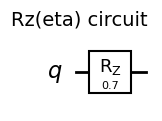

In [81]:
def Rn_matrix(n, eta):
    '''Builds Rn(eta) = cos(eta/2) I - i sin(eta/2) (n.sigma), directly from Eq. 3.8'''
    n = np.array(n) / np.linalg.norm(n)
    sx = np.array([[0, 1], [1, 0]])
    sy = np.array([[0, -1j], [1j, 0]])
    sz = np.array([[1, 0], [0, -1]])
    ndotsigma = n[0]*sx + n[1]*sy + n[2]*sz
    I = np.eye(2)
    return np.cos(eta/2)*I - 1j*np.sin(eta/2)*ndotsigma

def equal_up_to_phase(A, B, atol=1e-6):
    idx = np.unravel_index(np.argmax(np.abs(B)), B.shape)
    phase = A[idx] / B[idx]
    ok = np.allclose(A, phase * B, atol=atol)
    return ok, phase

eta0 = 0.7
n_axis = [0, 0, 1]
qc_rz_test = QuantumCircuit(1, name='Rz(eta) test')
qc_rz_test.rz(eta0, 0)
show_circuit(qc_rz_test, 'Rz(eta) circuit')

In [82]:
U_qiskit = Operator(qc_rz_test).data
U_notes = Rn_matrix(n_axis, eta0)
print('Rz(eta) from Qiskit:')
print(U_qiskit)
print('Rn(eta) from Eq. 3.8 with n = z:')
print(U_notes)
print('Match:', np.allclose(U_qiskit, U_notes))

Rz(eta) from Qiskit:
[[0.9394-0.3429j 0.    +0.j    ]
 [0.    +0.j     0.9394+0.3429j]]
Rn(eta) from Eq. 3.8 with n = z:
[[0.9394-0.3429j 0.    +0.j    ]
 [0.    +0.j     0.9394+0.3429j]]
Match: True


### Measurement in the Z basis vs the X basis

A plain `Rz` rotation on `|0>` leaves Z-basis probabilities unchanged (phase-only, Eq. 3.13-3.15). We need an X-basis (Hadamard) measurement to reveal it.

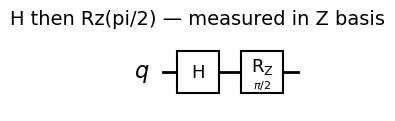

In [83]:
qc_zbasis = QuantumCircuit(1)
qc_zbasis.h(0)
qc_zbasis.rz(np.pi/2, 0)
show_circuit(qc_zbasis, 'H then Rz(pi/2) — measured in Z basis')

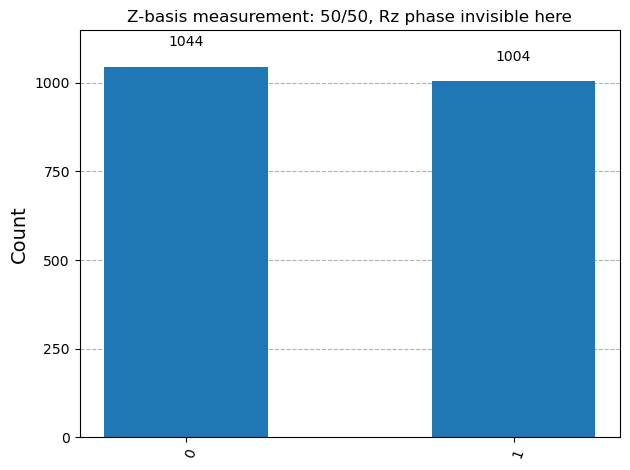

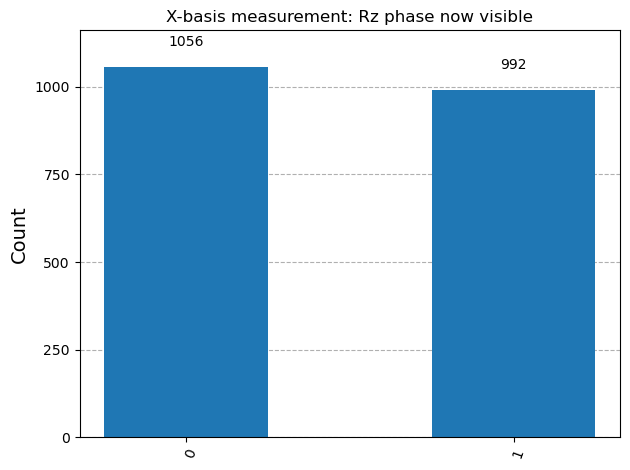

In [84]:
if AER_AVAILABLE:
    counts_z, fig_z, qcm_z = measure_and_plot(qc_zbasis, title='Z-basis measurement: 50/50, Rz phase invisible here')
    display(fig_z)

    qc_xbasis = qc_zbasis.copy()
    qc_xbasis.h(0)
    counts_x, fig_x, qcm_x = measure_and_plot(qc_xbasis, title='X-basis measurement: Rz phase now visible')
    display(fig_x)
    show_circuit(qcm_x, 'Full circuit with basis-change + measurement')

## 1.1 Rn(eta) <=> Rotation of the Bloch Vector (Eq. 3.9 – 3.21)

`Rz(eta)|theta,phi> = |theta, phi+eta>` (Eq. 3.13-3.15); `Rx(eta)|theta,pi/2> = |theta-eta, pi/2>` (Eq. 3.19-3.21).

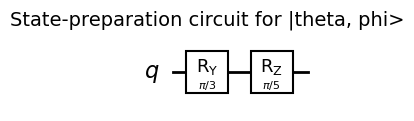

In [85]:
theta, phi, eta = np.pi/3, np.pi/5, np.pi/2

qc_in = QuantumCircuit(1, name='prepare |theta,phi>')
qc_in.ry(theta, 0)
qc_in.rz(phi, 0)
show_circuit(qc_in, 'State-preparation circuit for |theta, phi>')

Initial state |theta, phi>:


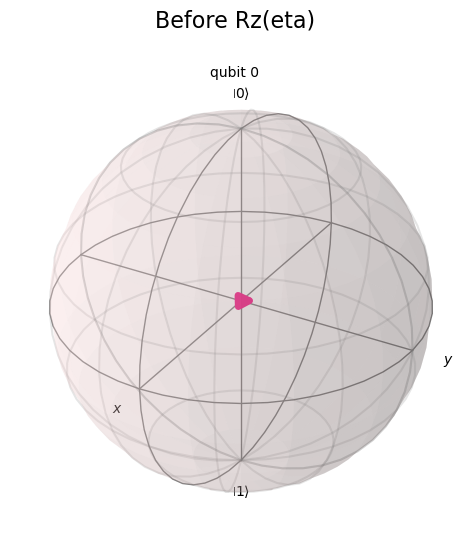

In [86]:
psi_in = Statevector(qc_in)
print('Initial state |theta, phi>:')
show_bloch(psi_in, 'Before Rz(eta)')

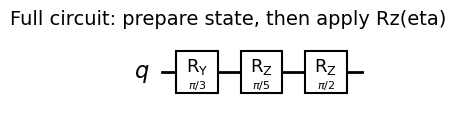

In [87]:
qc_out = qc_in.copy()
qc_out.rz(eta, 0)
psi_out = Statevector(qc_out)
show_circuit(qc_out, 'Full circuit: prepare state, then apply Rz(eta)')

After Rz(eta): expect |theta, phi + eta>


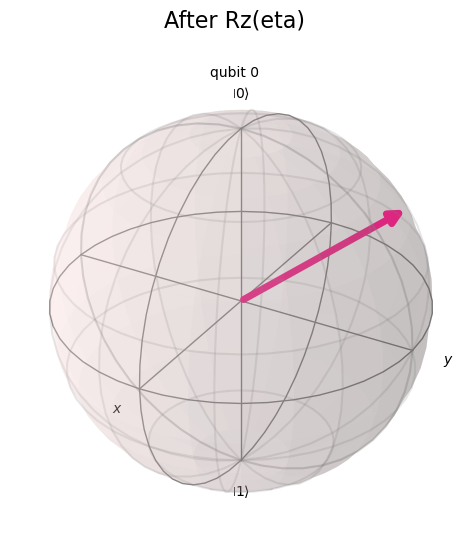

In [88]:
print('After Rz(eta): expect |theta, phi + eta>')
show_bloch(psi_out, 'After Rz(eta)')

In [89]:
def bloch_angles(sv):
    rho = DensityMatrix(sv).data
    x = 2*np.real(rho[0, 1])
    y = 2*np.imag(rho[1, 0])
    z = np.real(rho[0, 0] - rho[1, 1])
    theta_ = np.arccos(np.clip(z, -1, 1))
    phi_ = np.arctan2(y, x)
    return theta_, phi_

th_in, ph_in = bloch_angles(psi_in)
th_out, ph_out = bloch_angles(psi_out)
print(f'theta: {th_in:.3f} -> {th_out:.3f}  (should be unchanged)')
print(f'phi:   {ph_in:.3f} -> {ph_out:.3f}  (expected {(ph_in+eta):.3f} mod 2pi)')

theta: 1.047 -> 1.047  (should be unchanged)
phi:   0.628 -> 2.199  (expected 2.199 mod 2pi)


Now the `Rx(eta)` case: prepare a state in the y-z plane (`phi = pi/2`) and rotate about x. Theory (Eq. 3.19) predicts `theta -> theta - eta` while `phi` stays at `pi/2`.

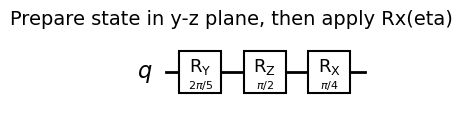

In [90]:
theta2, eta2 = 2*np.pi/5, np.pi/4
qc_in2 = QuantumCircuit(1)
qc_in2.ry(theta2, 0)
qc_in2.rz(np.pi/2, 0)
psi_in2 = Statevector(qc_in2)

qc_out2 = qc_in2.copy()
qc_out2.rx(eta2, 0)
psi_out2 = Statevector(qc_out2)

show_circuit(qc_out2, 'Prepare state in y-z plane, then apply Rx(eta)')

theta: 1.257 -> 0.471  (expected 0.471)
phi:   1.571 -> 1.571  (should stay pi/2 = 1.571)


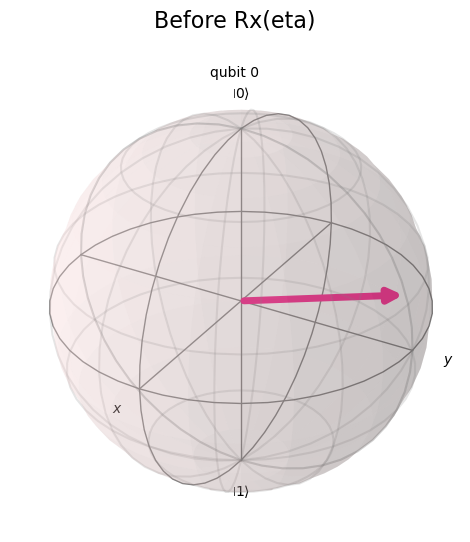

In [91]:
th_in2, ph_in2 = bloch_angles(psi_in2)
th_out2, ph_out2 = bloch_angles(psi_out2)
print(f'theta: {th_in2:.3f} -> {th_out2:.3f}  (expected {(th_in2-eta2):.3f})')
print(f'phi:   {ph_in2:.3f} -> {ph_out2:.3f}  (should stay pi/2 = {np.pi/2:.3f})')
show_bloch(psi_in2, 'Before Rx(eta)')

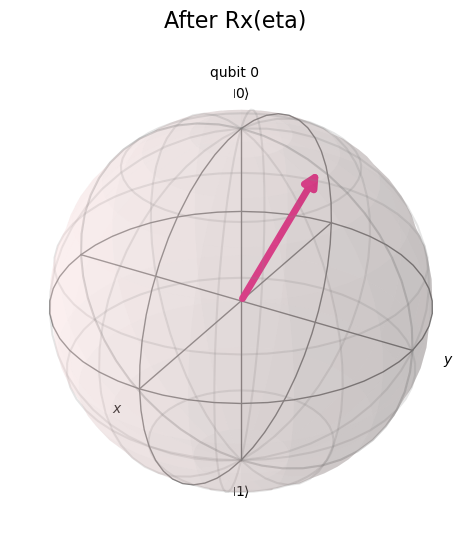

In [92]:
show_bloch(psi_out2, 'After Rx(eta)')

## 2. The Elementary Single-Qubit Gates (Sec. 3.1.2)

For every gate: circuit diagram, matrix, Bloch-sphere action, and (where probabilistic) a measurement histogram.

In [93]:
def gate_report(name, build_fn, eq_ref='', input_label='0'):
    qc = QuantumCircuit(1, name=name)
    build_fn(qc)
    print(f'=== {name} gate {eq_ref} ===')
    fig_c = show_circuit(qc, f'{name} gate circuit')
    display(fig_c)
    U = Operator(qc).data
    print('Matrix:')
    print(np.round(U, 3))
    sv_in = Statevector.from_label(input_label)
    full = QuantumCircuit(1)
    if input_label == '1':
        full.x(0)
    full.compose(qc, inplace=True)
    sv_out = Statevector(full)
    print(f'{name}|{input_label}> = {sv_out.data.round(3)}')
    display(show_bloch(sv_out, f'{name}|{input_label}> on Bloch sphere'))
    return qc

### 2.1 X gate (NOT gate) — Eq. 3.28 – 3.31

=== X gate (Eq. 3.28) ===


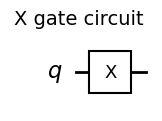

Matrix:
[[0.+0.j 1.+0.j]
 [1.+0.j 0.+0.j]]
X|0> = [0.+0.j 1.+0.j]


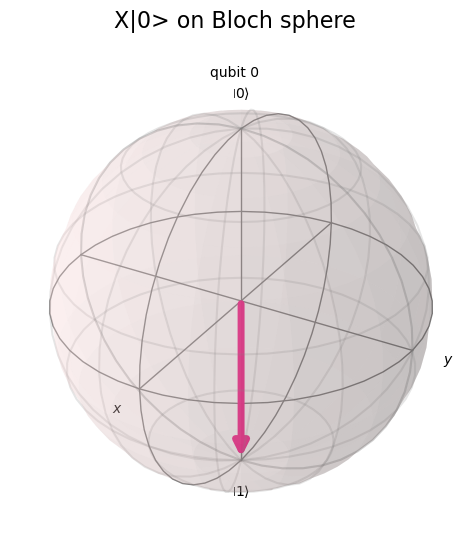

In [94]:
qc_x = gate_report('X', lambda qc: qc.x(0), '(Eq. 3.28)')

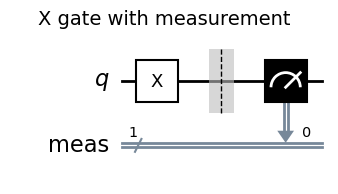

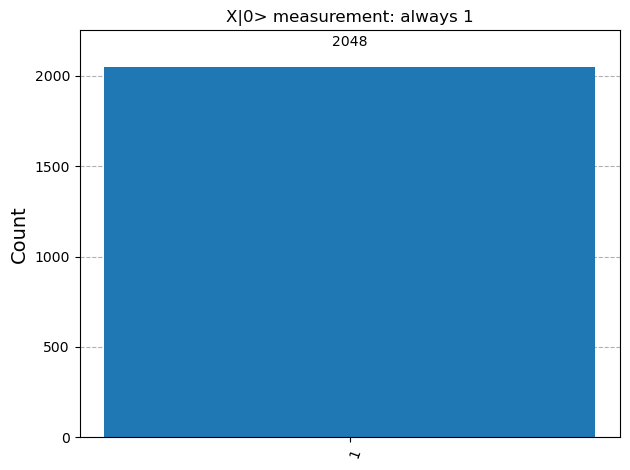

In [95]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_x, title='X|0> measurement: always 1')
    display(show_circuit(qcm, 'X gate with measurement'))
    display(fig)

### 2.2 Y gate — Eq. 3.32 – 3.35

=== Y gate (Eq. 3.32) ===


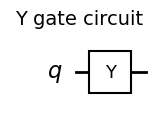

Matrix:
[[0.+0.j 0.-1.j]
 [0.+1.j 0.+0.j]]
Y|0> = [0.+0.j 0.+1.j]


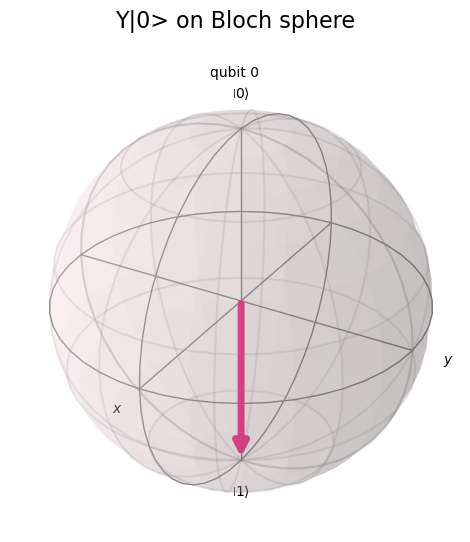

In [96]:
qc_y = gate_report('Y', lambda qc: qc.y(0), '(Eq. 3.32)')

### 2.3 Z gate — Eq. 3.36 – 3.39

=== Z gate (Eq. 3.36) ===


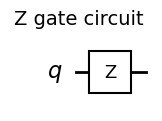

Matrix:
[[ 1.+0.j  0.+0.j]
 [ 0.+0.j -1.+0.j]]
Z|1> = [ 0.+0.j -1.+0.j]


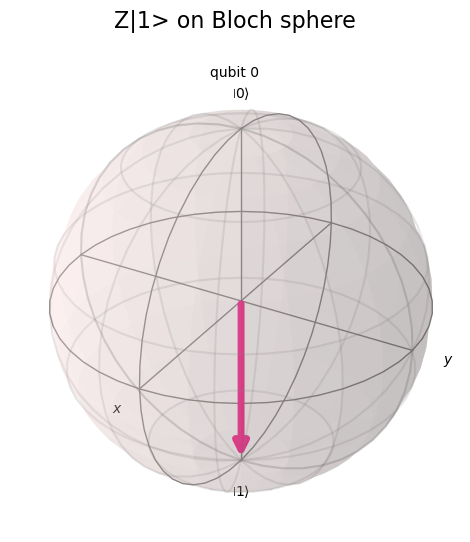

In [97]:
qc_z = gate_report('Z', lambda qc: qc.z(0), '(Eq. 3.36)', input_label='1')

In [98]:
if AER_AVAILABLE:
    qc_zphase = QuantumCircuit(1)
    qc_zphase.h(0)
    qc_zphase.z(0)
    qc_zphase.h(0)
    show_circuit(qc_zphase, 'H - Z - H reveals the Z phase flip in Z-basis measurement')

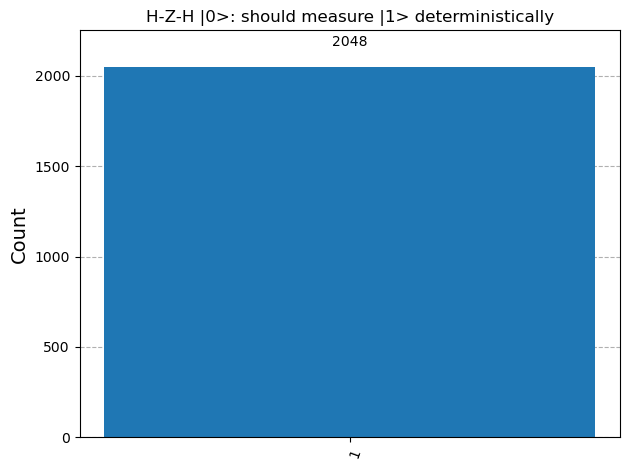

In [99]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_zphase, title='H-Z-H |0>: should measure |1> deterministically')
    display(fig)

### 2.4 T (pi/8) gate — Eq. 3.40 – 3.43

=== T gate (Eq. 3.40) ===


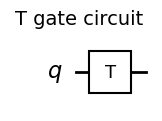

Matrix:
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
T|1> = [0.   +0.j    0.707+0.707j]


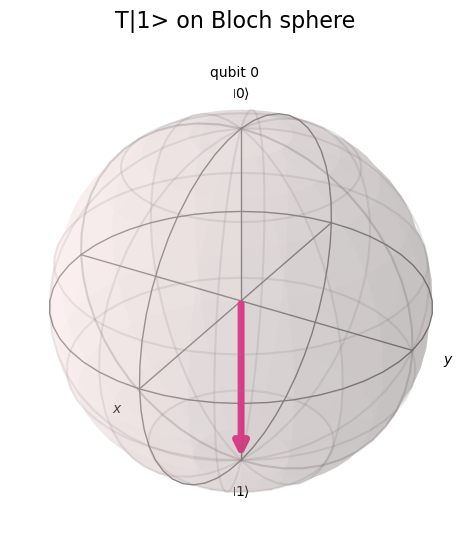

T from Eq. 3.43:
[[1.   +0.j    0.   +0.j   ]
 [0.   +0.j    0.707+0.707j]]
Matches Qiskit T gate: True


In [100]:
qc_t = gate_report('T', lambda qc: qc.t(0), '(Eq. 3.40)', input_label='1')

Z_mat = np.array([[1, 0], [0, -1]])
T_formula = np.exp(1j*np.pi/8) * (np.cos(np.pi/8)*np.eye(2) - 1j*np.sin(np.pi/8)*Z_mat)
print('T from Eq. 3.43:')
print(np.round(T_formula, 3))
print('Matches Qiskit T gate:', np.allclose(Operator(qc_t).data, T_formula))

### 2.5 S gate — Eq. 3.44 – 3.48 (note `S = T^2`)

=== S gate (Eq. 3.44) ===


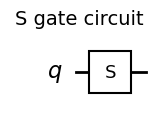

Matrix:
[[1.+0.j 0.+0.j]
 [0.+0.j 0.+1.j]]
S|1> = [0.+0.j 0.+1.j]


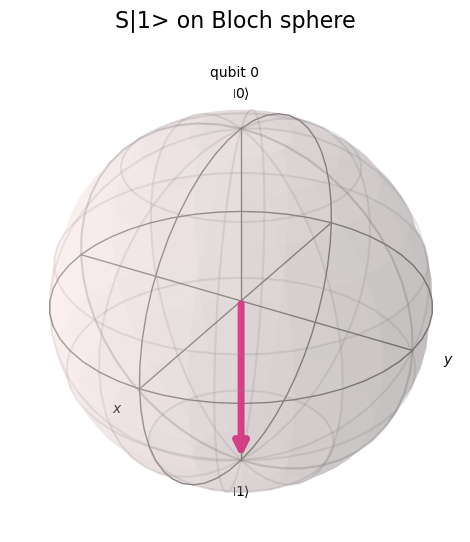

T^2 == S ? True


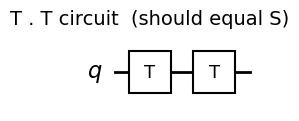

In [101]:
qc_s = gate_report('S', lambda qc: qc.s(0), '(Eq. 3.44)', input_label='1')

qc_t2 = QuantumCircuit(1)
qc_t2.t(0)
qc_t2.t(0)
print('T^2 == S ?', np.allclose(Operator(qc_t2).data, Operator(qc_s).data))
show_circuit(qc_t2, 'T . T circuit  (should equal S)')

### 2.6 Hadamard gate — Eq. 3.49 – 3.55 (`H = (X+Z)/sqrt(2)`, Eq. 3.52)

=== H gate (Eq. 3.49) ===


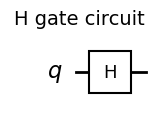

Matrix:
[[ 0.707+0.j  0.707+0.j]
 [ 0.707+0.j -0.707+0.j]]
H|0> = [0.707+0.j 0.707+0.j]


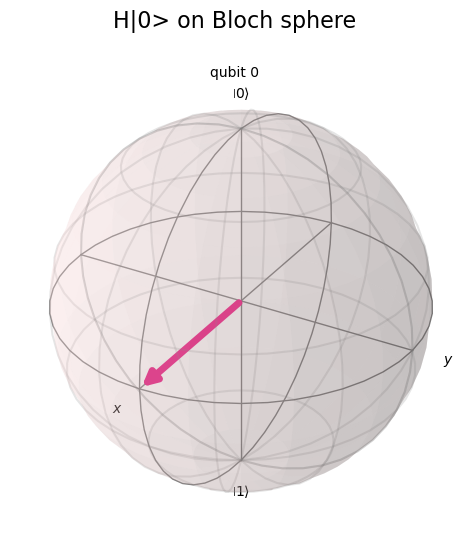

H = (X+Z)/sqrt(2)  (Eq. 3.52):
[[ 0.707  0.707]
 [ 0.707 -0.707]]
Matches Qiskit H gate: True


In [102]:
qc_h = gate_report('H', lambda qc: qc.h(0), '(Eq. 3.49)')

X_mat = np.array([[0, 1], [1, 0]])
Z_mat = np.array([[1, 0], [0, -1]])
H_formula = (X_mat + Z_mat) / np.sqrt(2)
print('H = (X+Z)/sqrt(2)  (Eq. 3.52):')
print(np.round(H_formula, 3))
print('Matches Qiskit H gate:', np.allclose(Operator(qc_h).data, H_formula))

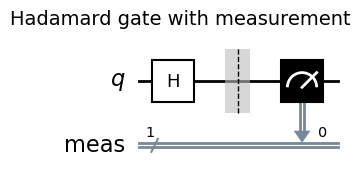

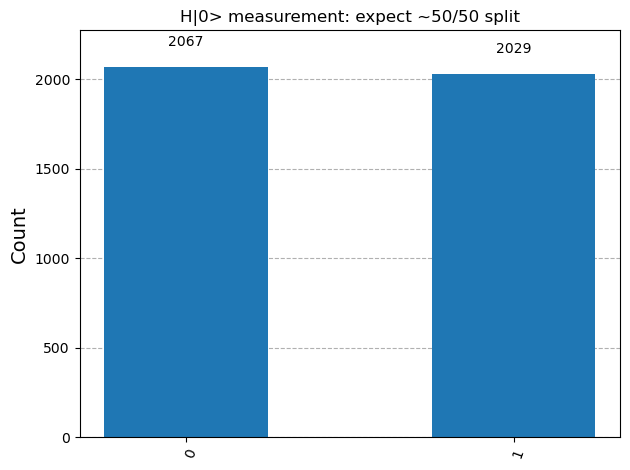

Counts: {'1': 2029, '0': 2067}


In [103]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_h, shots=4096, title='H|0> measurement: expect ~50/50 split')
    display(show_circuit(qcm, 'Hadamard gate with measurement'))
    display(fig)
    print('Counts:', counts)

## 3. Single-Qubit Universal Gates: H and T (Sec. 3.1.3)

`H T H = exp(i pi/8) (cos(pi/8) I - i sin(pi/8) X)` (Eq. 3.56). `T H T H = Rp(eta)`, with `cos(eta/2) = cos^2(pi/8)` (Eq. 3.60-3.71), and `eta/pi` is irrational.

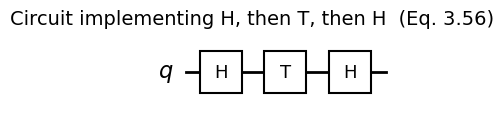

In [104]:
qc_hth = QuantumCircuit(1, name='H.T.H')
qc_hth.h(0)
qc_hth.t(0)
qc_hth.h(0)
show_circuit(qc_hth, 'Circuit implementing H, then T, then H  (Eq. 3.56)')

In [105]:
HTH = Operator(qc_hth).data
print('Matrix of H.T.H:')
print(np.round(HTH, 3))
formula = np.exp(1j*np.pi/8) * (np.cos(np.pi/8)*np.eye(2) - 1j*np.sin(np.pi/8)*X_mat)
print('Formula from Eq. 3.56:')
print(np.round(formula, 3))
print('Exact match:', np.allclose(HTH, formula))

Matrix of H.T.H:
[[0.854+0.354j 0.146-0.354j]
 [0.146-0.354j 0.854+0.354j]]
Formula from Eq. 3.56:
[[0.854+0.354j 0.146-0.354j]
 [0.146-0.354j 0.854+0.354j]]
Exact match: True


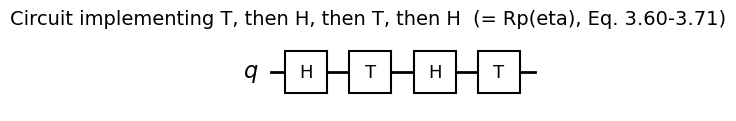

In [106]:
qc_thth = QuantumCircuit(1, name='T.H.T.H')
qc_thth.h(0)
qc_thth.t(0)
qc_thth.h(0)
qc_thth.t(0)
show_circuit(qc_thth, 'Circuit implementing T, then H, then T, then H  (= Rp(eta), Eq. 3.60-3.71)')

In [107]:
THTH = Operator(qc_thth).data
eta_p = 2*np.arccos(np.cos(np.pi/8)**2)
print('eta (Eq. 3.71) =', eta_p, ' ; eta/pi =', eta_p/np.pi, ' (irrational -> gate never exactly repeats)')

p_axis = np.array([np.cos(np.pi/8), np.sin(np.pi/8), np.cos(np.pi/8)])
Rp_eta = Rn_matrix(p_axis, eta_p)
ok, phase = equal_up_to_phase(THTH, Rp_eta)
print('T.H.T.H equals Rp(eta) up to global phase?', ok)

eta (Eq. 3.71) = 1.0960568152406256  ; eta/pi = 0.34888572011021163  (irrational -> gate never exactly repeats)
T.H.T.H equals Rp(eta) up to global phase? True


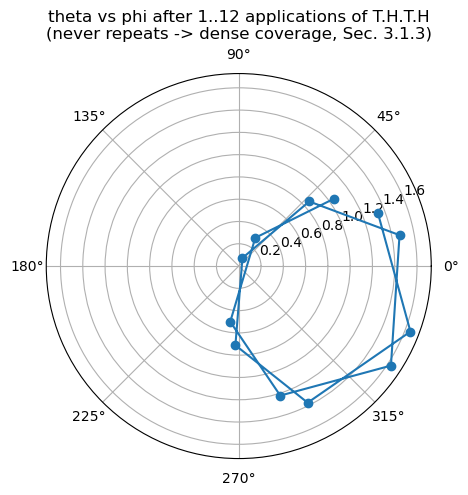

In [108]:
if AER_AVAILABLE:
    thetas, phis = [], []
    for reps in range(1, 13):
        qc_r = QuantumCircuit(1)
        qc_r.h(0)
        for _ in range(reps):
            qc_r.t(0); qc_r.h(0); qc_r.t(0); qc_r.h(0)
        sv = Statevector(qc_r)
        th, ph = bloch_angles(sv)
        thetas.append(th); phis.append(ph)
    plt.figure(figsize=(5,5))
    ax = plt.subplot(111, projection='polar')
    ax.plot(phis, thetas, 'o-')
    ax.set_title('theta vs phi after 1..12 applications of T.H.T.H\n(never repeats -> dense coverage, Sec. 3.1.3)')
    plt.show()

## 4. Multi-Qubit States and Controlled Gates (Sec. 3.1.4)

`CU |a,b> = U^(2^a) |a,b>` (Eq. 3.81).

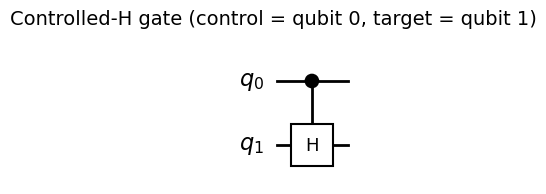

In [109]:
U = Operator(qc_h).data
cU = UnitaryGate(U, label='H').control(1)

qc_cu = QuantumCircuit(2, name='controlled-H')
qc_cu.append(cU, [0, 1])
show_circuit(qc_cu, 'Controlled-H gate (control = qubit 0, target = qubit 1)')

In [110]:
for a in ['0', '1']:
    for b in ['0', '1']:
        label = a + b
        out = Statevector.from_label(label).evolve(qc_cu)
        print(f'CU|{a},{b}> = {out.data.round(3)}')

CU|0,0> = [1.+0.j 0.-0.j 0.+0.j 0.-0.j]
CU|0,1> = [-0.   -0.j  0.707+0.j -0.   -0.j  0.707+0.j]
CU|1,0> = [-0.+0.j  0.-0.j  1.-0.j  0.-0.j]
CU|1,1> = [-0.   -0.j  0.707-0.j  0.   -0.j -0.707+0.j]


### 4.1 CNOT / Controlled-X gate — Eq. 3.82

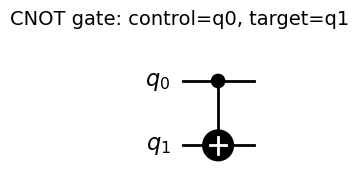

In [111]:
qc_cx = QuantumCircuit(2, name='CNOT')
qc_cx.cx(0, 1)
show_circuit(qc_cx, 'CNOT gate: control=q0, target=q1')

In [112]:
if AER_AVAILABLE:
    print('Truth table via MEASUREMENT (not just statevector algebra):')
    for a in [0, 1]:
        for b in [0, 1]:
            qc_test = QuantumCircuit(2)
            if a: qc_test.x(0)
            if b: qc_test.x(1)
            qc_test.cx(0, 1)
            counts, fig, qcm = measure_and_plot(qc_test, shots=256)
            print(f'input a={a}, b={b}  ->  counts = {counts}   (expect b_out = {a^b}, a_out = {a})')

Truth table via MEASUREMENT (not just statevector algebra):
input a=0, b=0  ->  counts = {'00': 256}   (expect b_out = 0, a_out = 0)
input a=0, b=1  ->  counts = {'10': 256}   (expect b_out = 1, a_out = 0)
input a=1, b=0  ->  counts = {'11': 256}   (expect b_out = 1, a_out = 1)
input a=1, b=1  ->  counts = {'01': 256}   (expect b_out = 0, a_out = 1)


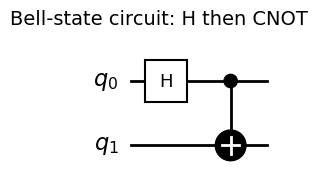

In [113]:
qc_bell = QuantumCircuit(2, name='Bell state')
qc_bell.h(0)
qc_bell.cx(0, 1)
show_circuit(qc_bell, 'Bell-state circuit: H then CNOT')

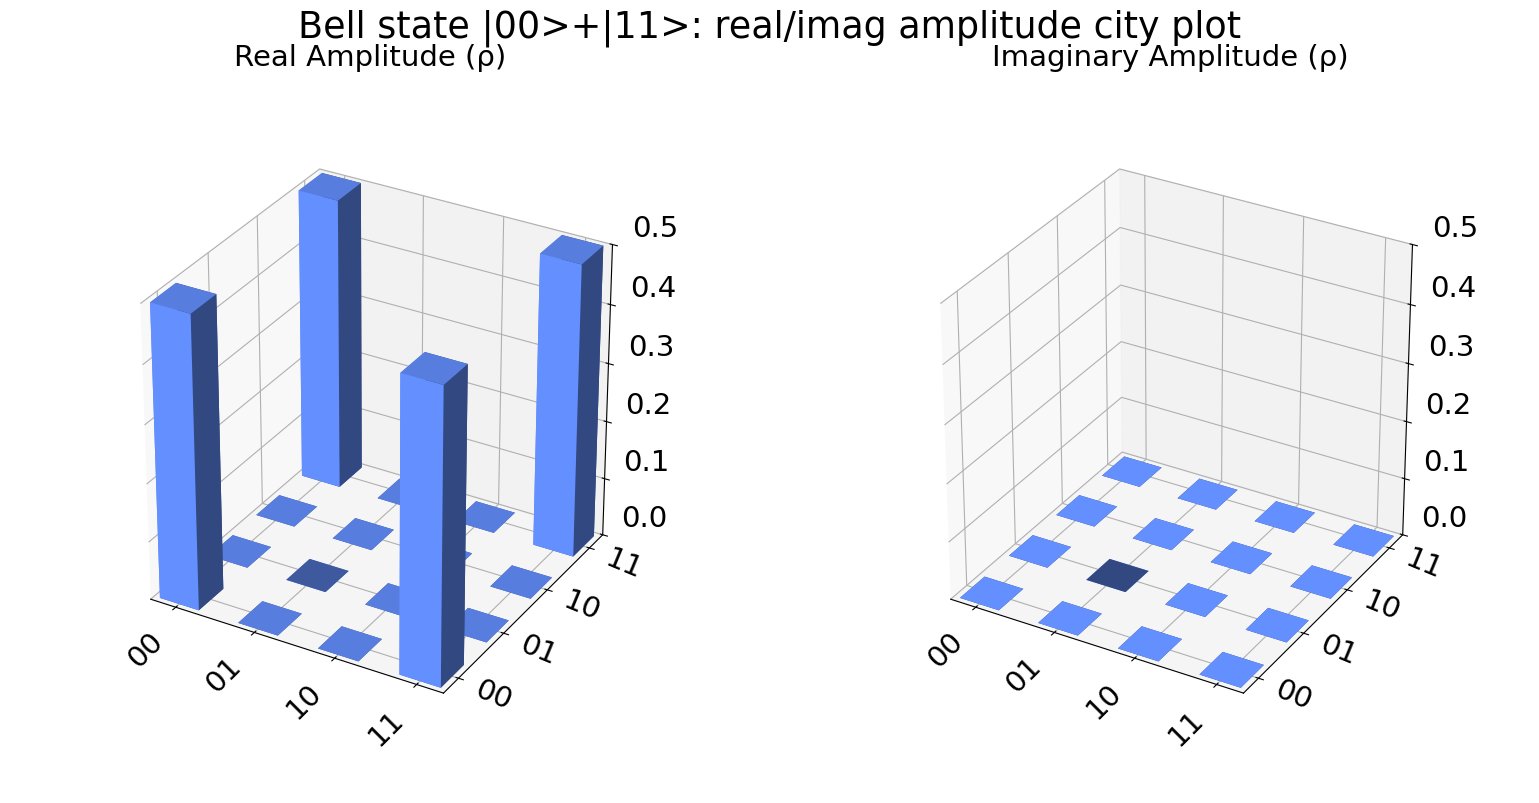

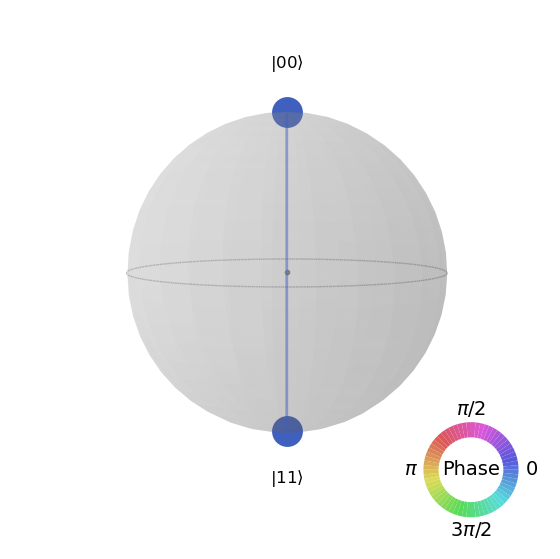

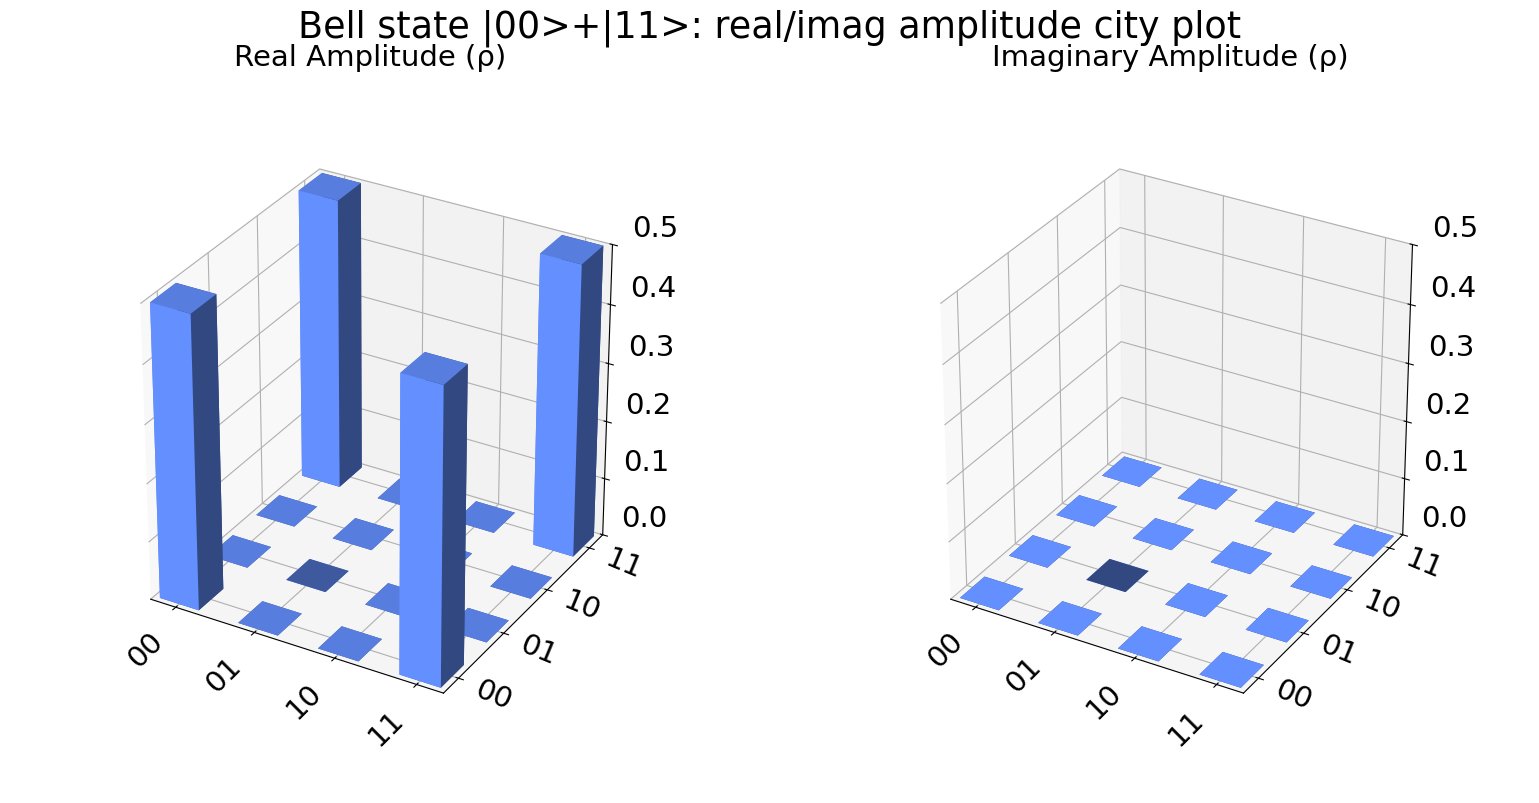

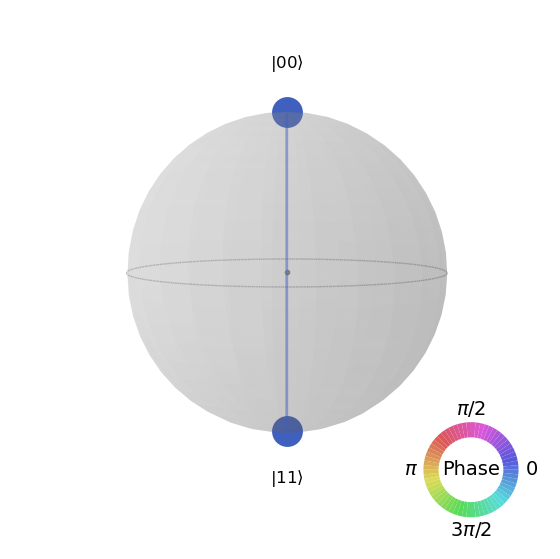

In [114]:
sv_bell = Statevector(qc_bell)
display(plot_state_city(sv_bell, title='Bell state |00>+|11>: real/imag amplitude city plot'))
display(plot_state_qsphere(sv_bell))

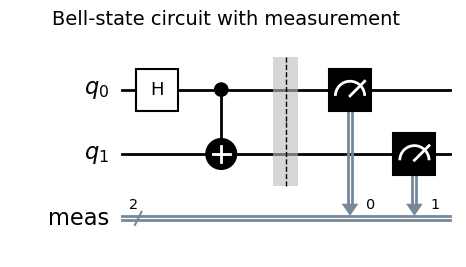

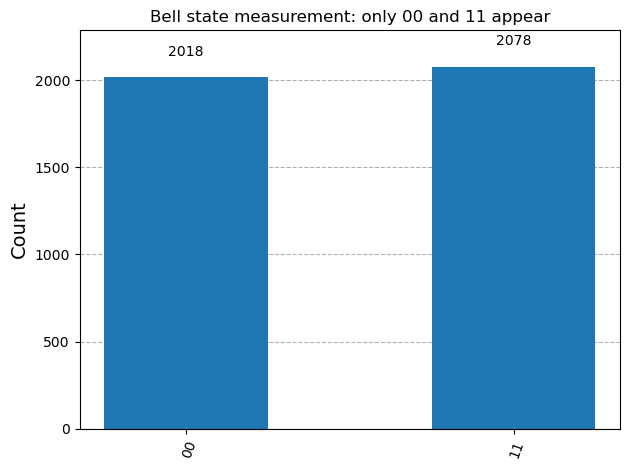

Counts: {'11': 2078, '00': 2018}


In [115]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_bell, shots=4096, title='Bell state measurement: only 00 and 11 appear')
    display(show_circuit(qcm, 'Bell-state circuit with measurement'))
    display(fig)
    print('Counts:', counts)

### 4.2 SWAP gate — Eq. 3.83 – 3.85, Fig. 3.10

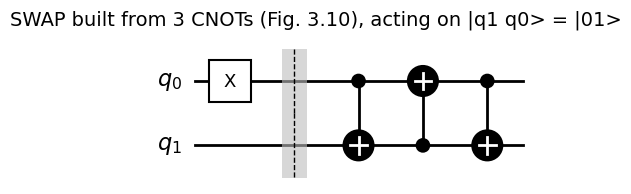

In [116]:
qc_swap_manual = QuantumCircuit(2, name='SWAP (3-CNOT)')
qc_swap_manual.x(0)
qc_swap_manual.barrier()
qc_swap_manual.cx(0, 1)
qc_swap_manual.cx(1, 0)
qc_swap_manual.cx(0, 1)
show_circuit(qc_swap_manual, 'SWAP built from 3 CNOTs (Fig. 3.10), acting on |q1 q0> = |01>')

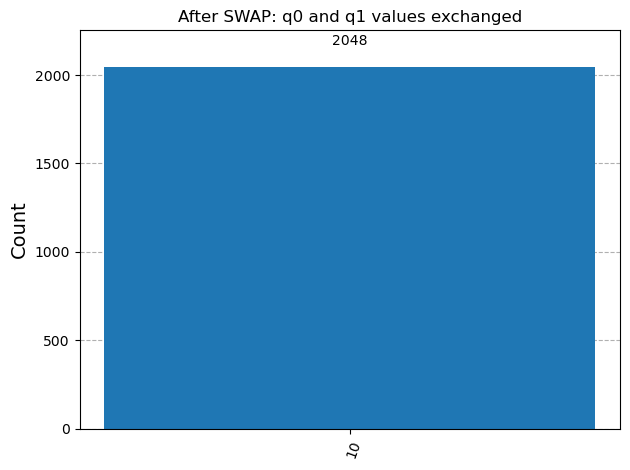

Counts: {'10': 2048}  (input was q0=1,q1=0 -> expect q0=0,q1=1 after swap)


In [117]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_swap_manual, title='After SWAP: q0 and q1 values exchanged')
    display(fig)
    print('Counts:', counts, ' (input was q0=1,q1=0 -> expect q0=0,q1=1 after swap)')

### 4.3 Control-by-|0> vs Control-by-|1> — Fig. 3.11

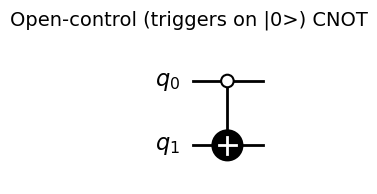

In [118]:
qc_open_ctrl = QuantumCircuit(2, name='open-control CX')
qc_open_ctrl.cx(0, 1, ctrl_state=0)
show_circuit(qc_open_ctrl, 'Open-control (triggers on |0>) CNOT')

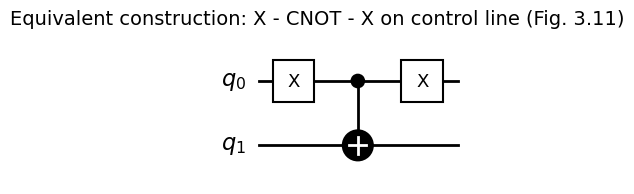

In [119]:
qc_via_X = QuantumCircuit(2, name='X-CX-X equivalent')
qc_via_X.x(0)
qc_via_X.cx(0, 1)
qc_via_X.x(0)
show_circuit(qc_via_X, 'Equivalent construction: X - CNOT - X on control line (Fig. 3.11)')

In [120]:
print('Open-control CX == X-CX-X ?', np.allclose(Operator(qc_open_ctrl).data, Operator(qc_via_X).data))

Open-control CX == X-CX-X ? True


## 5. n-Control Qubit Gates (Sec. 3.1.5)

### 5.1 Toffoli gate (CCX) — Fig. 3.12 – 3.13

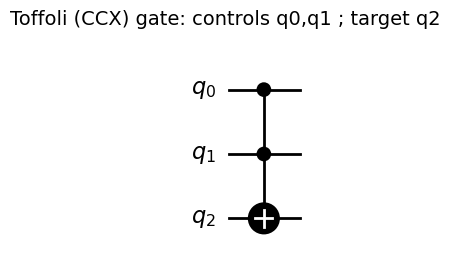

In [121]:
qc_ccx = QuantumCircuit(3, name='Toffoli')
qc_ccx.ccx(0, 1, 2)
show_circuit(qc_ccx, 'Toffoli (CCX) gate: controls q0,q1 ; target q2')

In [122]:
if AER_AVAILABLE:
    print('Truth table for Toffoli via MEASUREMENT:')
    for a in [0, 1]:
        for b in [0, 1]:
            for c in [0, 1]:
                qc_test = QuantumCircuit(3)
                if a: qc_test.x(0)
                if b: qc_test.x(1)
                if c: qc_test.x(2)
                qc_test.ccx(0, 1, 2)
                counts, fig, qcm = measure_and_plot(qc_test, shots=256)
                print(f'a={a} b={b} c={c}  ->  counts={counts}  (expect c_out={c ^ (a & b)})')

Truth table for Toffoli via MEASUREMENT:
a=0 b=0 c=0  ->  counts={'000': 256}  (expect c_out=0)
a=0 b=0 c=1  ->  counts={'100': 256}  (expect c_out=1)
a=0 b=1 c=0  ->  counts={'010': 256}  (expect c_out=0)
a=0 b=1 c=1  ->  counts={'110': 256}  (expect c_out=1)
a=1 b=0 c=0  ->  counts={'001': 256}  (expect c_out=0)
a=1 b=0 c=1  ->  counts={'101': 256}  (expect c_out=1)
a=1 b=1 c=0  ->  counts={'111': 256}  (expect c_out=1)
a=1 b=1 c=1  ->  counts={'011': 256}  (expect c_out=0)


### 5.2 Multi-Controlled-X (Cn gate) — Fig. 3.15

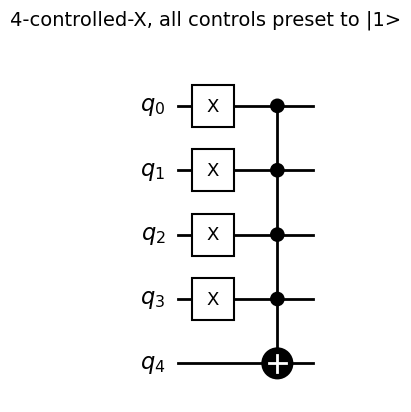

In [123]:
n_controls = 4
mcx = MCXGate(n_controls)
qc_mcx = QuantumCircuit(n_controls + 1, name=f'{n_controls}-controlled-X')
for q in range(n_controls):
    qc_mcx.x(q)
qc_mcx.append(mcx, range(n_controls + 1))
show_circuit(qc_mcx, f'{n_controls}-controlled-X, all controls preset to |1>')

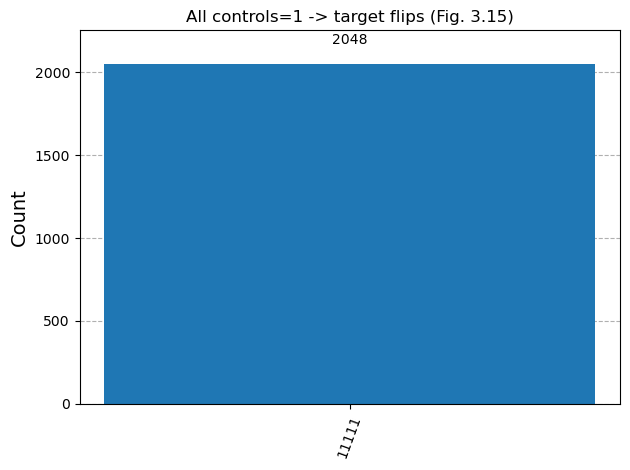

Counts: {'11111': 2048}


In [124]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_mcx, title='All controls=1 -> target flips (Fig. 3.15)')
    display(fig)
    print('Counts:', counts)

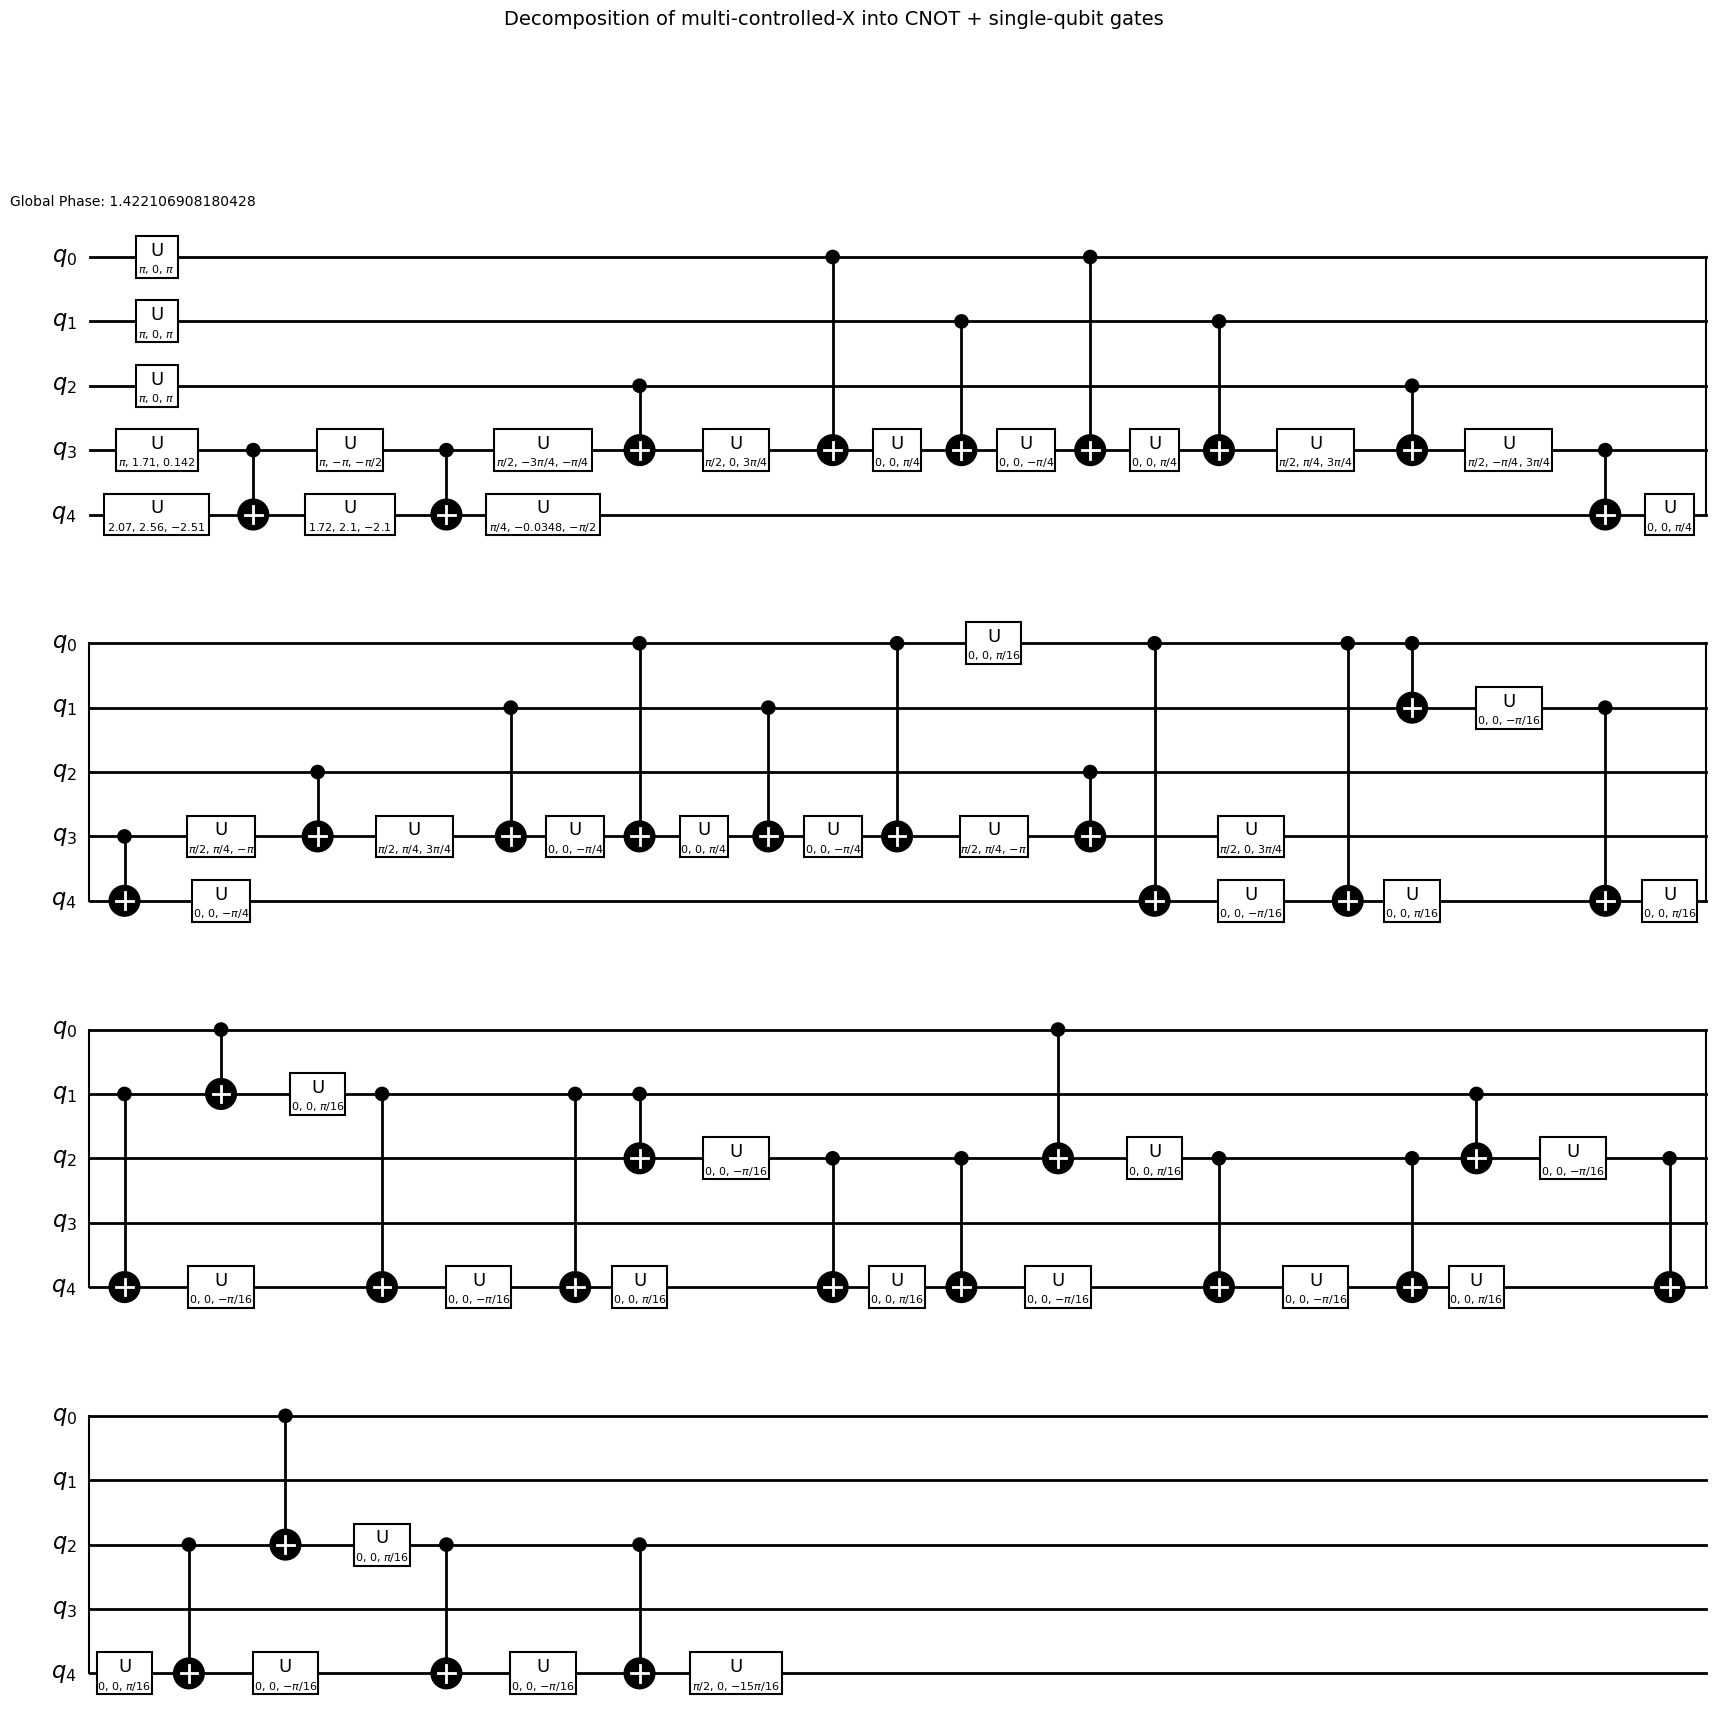

In [125]:
qc_mcx_decomp = transpile(qc_mcx, basis_gates=['u', 'cx'])
show_circuit(qc_mcx_decomp, 'Decomposition of multi-controlled-X into CNOT + single-qubit gates')

## 6. The Controlled-Phase Gate (Sec. 3.1.7) — Phase Kickback

A phase factor `exp(i alpha)` should appear ONLY when the control is `|1>` (Eq. 3.100).

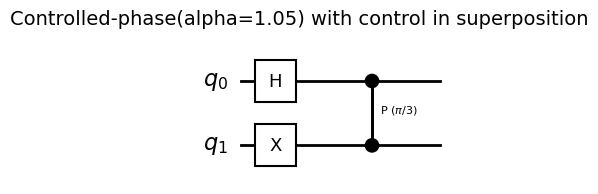

In [126]:
alpha = np.pi / 3
qc_cp = QuantumCircuit(2, name='controlled-phase')
qc_cp.h(0)
qc_cp.x(1)
qc_cp.cp(alpha, 0, 1)
show_circuit(qc_cp, f'Controlled-phase(alpha={alpha:.2f}) with control in superposition')

Measured relative phase between q0=0 and q0=1 components: 1.0471975511965976
Expected (Eq. 3.100 with a=1): 1.0471975511965976


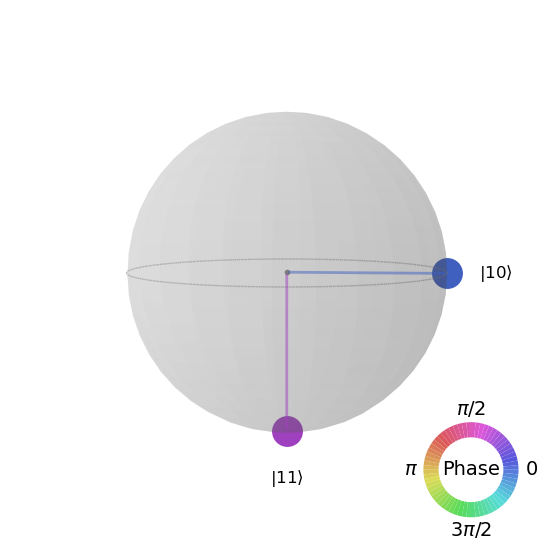

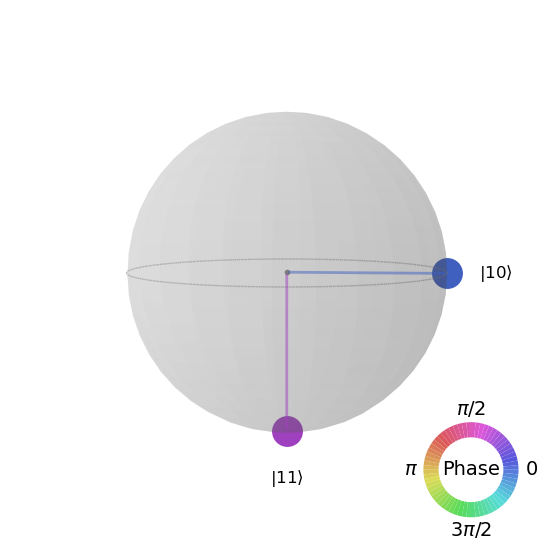

In [127]:
sv = Statevector(qc_cp)
amp_q0_0 = sv.data[2]
amp_q0_1 = sv.data[3]
measured_phase = np.angle(amp_q0_1) - np.angle(amp_q0_0)
print('Measured relative phase between q0=0 and q0=1 components:', measured_phase)
print('Expected (Eq. 3.100 with a=1):', alpha)
display(plot_state_qsphere(sv))

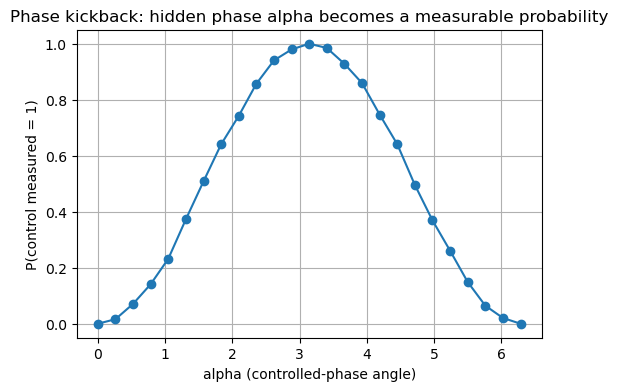

In [128]:
if AER_AVAILABLE:
    alphas = np.linspace(0, 2*np.pi, 25)
    p1_list = []
    for a_ in alphas:
        qc_pk = QuantumCircuit(2)
        qc_pk.h(0)
        qc_pk.x(1)
        qc_pk.cp(a_, 0, 1)
        qc_pk.h(0)
        counts, _, _ = measure_and_plot(qc_pk, shots=2048)
        p1 = sum(v for k, v in counts.items() if k[-1] == '1') / 2048
        p1_list.append(p1)
    plt.figure(figsize=(6,4))
    plt.plot(alphas, p1_list, 'o-')
    plt.xlabel('alpha (controlled-phase angle)')
    plt.ylabel('P(control measured = 1)')
    plt.title('Phase kickback: hidden phase alpha becomes a measurable probability')
    plt.grid(True)
    plt.show()

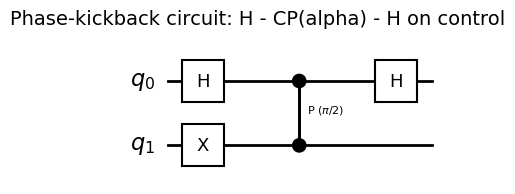

In [129]:
qc_pk_example = QuantumCircuit(2, name='phase kickback')
qc_pk_example.h(0)
qc_pk_example.x(1)
qc_pk_example.cp(np.pi/2, 0, 1)
qc_pk_example.h(0)
show_circuit(qc_pk_example, 'Phase-kickback circuit: H - CP(alpha) - H on control')

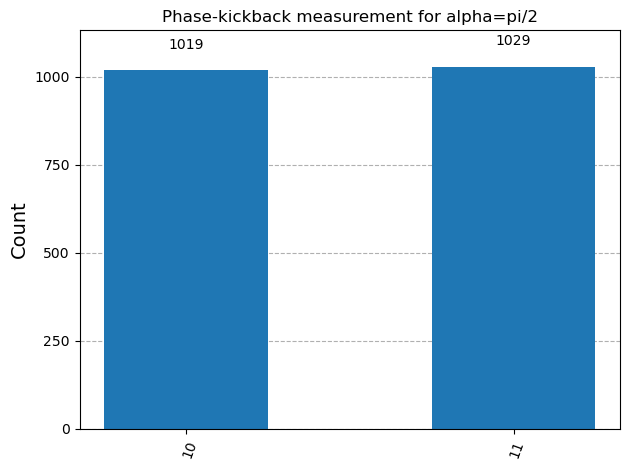

In [130]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_pk_example, title='Phase-kickback measurement for alpha=pi/2')
    display(fig)

## 7. The No-Cloning Theorem (Sec. 3.2)

No unitary can copy an arbitrary unknown state (Eq. 3.176-3.178).

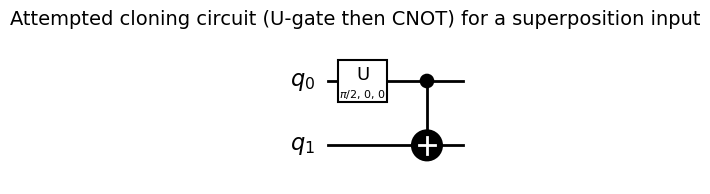

In [131]:
def attempted_clone_circuit(theta, phi):
    qc = QuantumCircuit(2, name='attempted clone')
    qc.u(theta, phi, 0, 0)
    qc.cx(0, 1)
    return qc

qc_clone_basis = attempted_clone_circuit(0.0, 0.0)
qc_clone_super = attempted_clone_circuit(np.pi/2, 0.0)

show_circuit(qc_clone_super, 'Attempted cloning circuit (U-gate then CNOT) for a superposition input')

In [132]:
def ideal_clone(theta, phi):
    single = QuantumCircuit(1)
    single.u(theta, phi, 0, 0)
    psi = Statevector(single)
    return psi.tensor(psi)

print('theta      fidelity with ideal clone |psi>|psi>')
for th in np.linspace(0, np.pi, 7):
    actual = Statevector(attempted_clone_circuit(th, 0.0))
    ideal = ideal_clone(th, 0.0)
    fid = state_fidelity(actual, ideal)
    print(f'{th:6.3f}       {fid:6.3f}')

theta      fidelity with ideal clone |psi>|psi>
 0.000        1.000
 0.524        0.844
 1.047        0.600
 1.571        0.500
 2.094        0.600
 2.618        0.844
 3.142        1.000


Measurement view: basis-state input looks like cloning; superposition input creates entanglement instead of two independent copies.

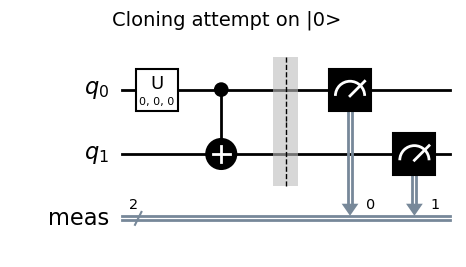

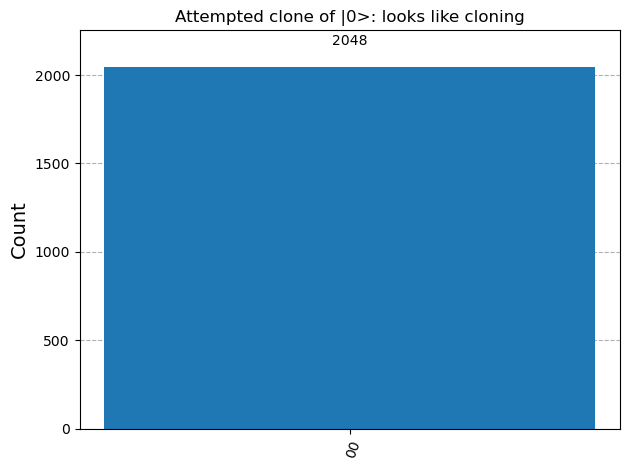

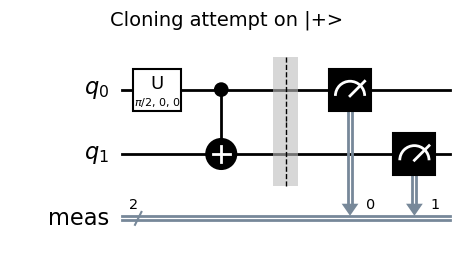

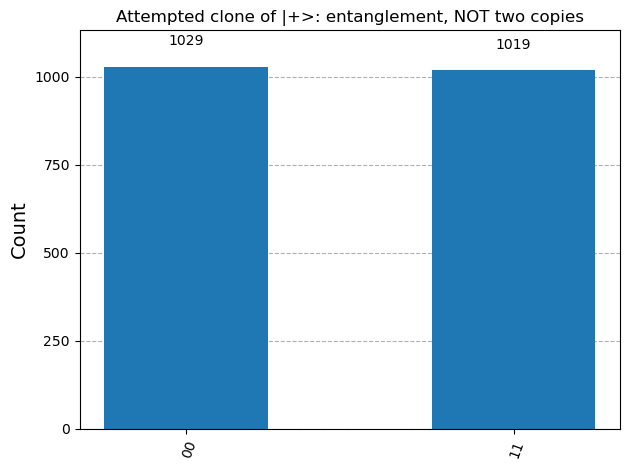

In [133]:
if AER_AVAILABLE:
    counts_basis, fig_basis, qcm_basis = measure_and_plot(qc_clone_basis, shots=2048,
                                                            title='Attempted clone of |0>: looks like cloning')
    display(show_circuit(qcm_basis, 'Cloning attempt on |0>'))
    display(fig_basis)

    counts_super, fig_super, qcm_super = measure_and_plot(qc_clone_super, shots=2048,
                                                            title='Attempted clone of |+>: entanglement, NOT two copies')
    display(show_circuit(qcm_super, 'Cloning attempt on |+>'))
    display(fig_super)

Key check: if cloning worked, measuring BOTH qubits in the X-basis should give only `00`.

In [134]:
if AER_AVAILABLE:
    qc_clone_xbasis = attempted_clone_circuit(np.pi/2, 0.0)
    qc_clone_xbasis.h(0)
    qc_clone_xbasis.h(1)
    show_circuit(qc_clone_xbasis, 'Cloning attempt on |+>, then measure BOTH qubits in the X basis')

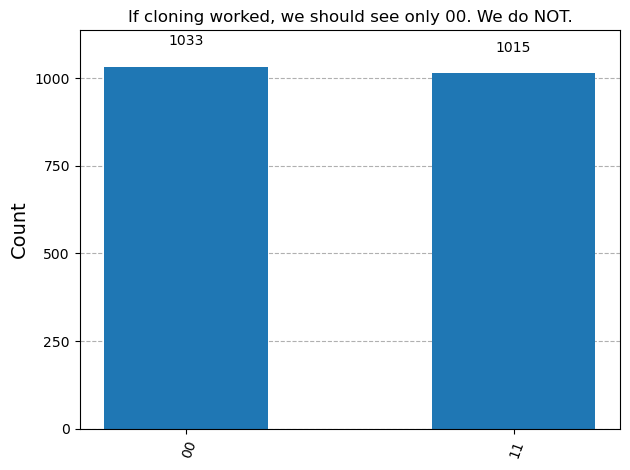

Counts: {'00': 1033, '11': 1015}


In [135]:
if AER_AVAILABLE:
    counts, fig, qcm = measure_and_plot(qc_clone_xbasis, shots=2048,
                                         title='If cloning worked, we should see only 00. We do NOT.')
    display(fig)
    print('Counts:', counts)

The histogram shows a spread across outcomes — direct experimental confirmation of the no-cloning theorem (Eq. 3.178).

## 8. Bonus: Deutsch's Algorithm (Sec. 4.1.1) — Full Circuits + Measurements

Oracle: `Uf|x>|y> = |x>|y XOR f(x)>` (Eq. 4.9).

In [136]:
def deutsch_oracle(kind):
    qc = QuantumCircuit(2, name=f'Uf_{kind}')
    if kind == 'balanced_identity':
        qc.cx(0, 1)
    elif kind == 'balanced_not':
        qc.cx(0, 1)
        qc.x(1)
    elif kind == 'constant_1':
        qc.x(1)
    return qc

def deutsch_circuit(kind):
    qc = QuantumCircuit(2, 1, name=f'Deutsch[{kind}]')
    qc.x(1)
    qc.h(0)
    qc.h(1)
    qc.barrier()
    qc.append(deutsch_oracle(kind).to_gate(label=f'Uf[{kind}]'), [0, 1])
    qc.barrier()
    qc.h(0)
    qc.measure(0, 0)
    return qc

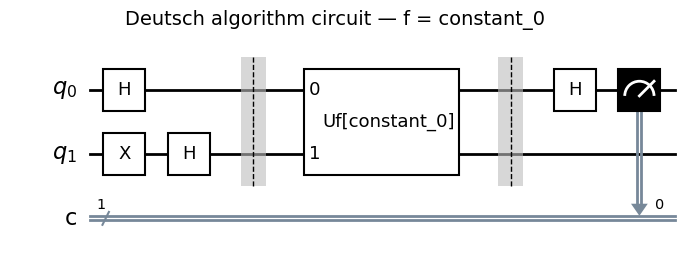

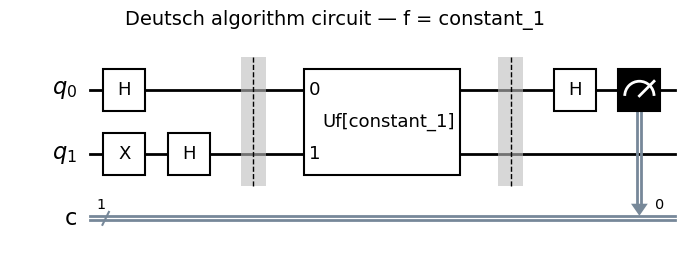

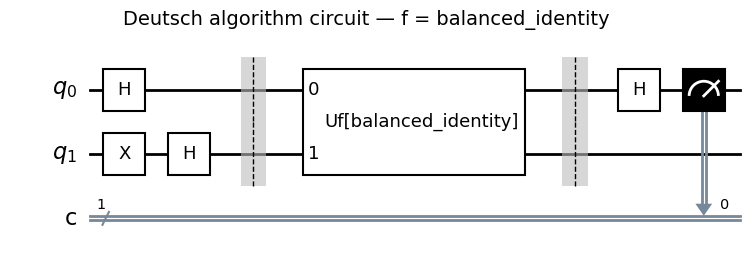

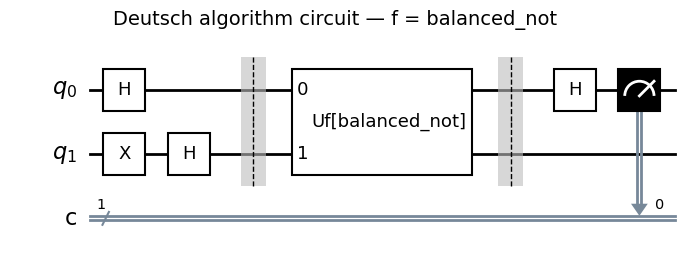

In [137]:
for kind in ['constant_0', 'constant_1', 'balanced_identity', 'balanced_not']:
    qc_d = deutsch_circuit(kind)
    display(show_circuit(qc_d, f'Deutsch algorithm circuit — f = {kind}'))

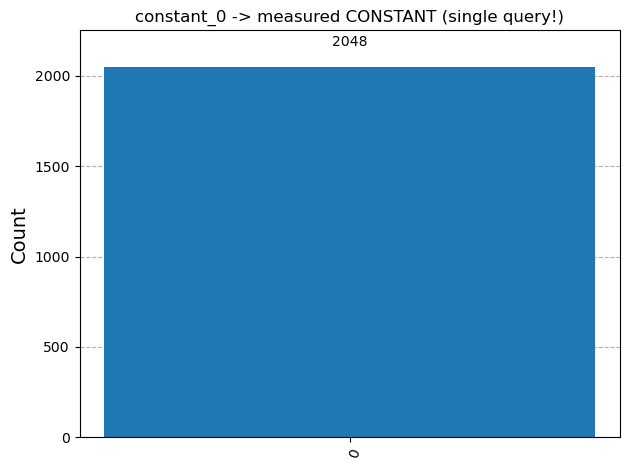

constant_0 -> {'0': 2048} -> CONSTANT


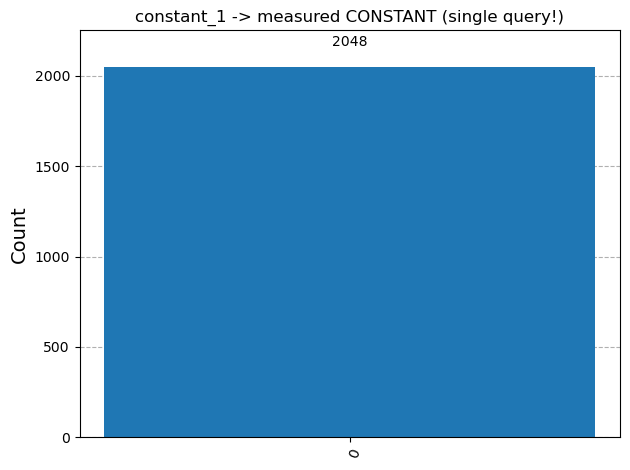

constant_1 -> {'0': 2048} -> CONSTANT


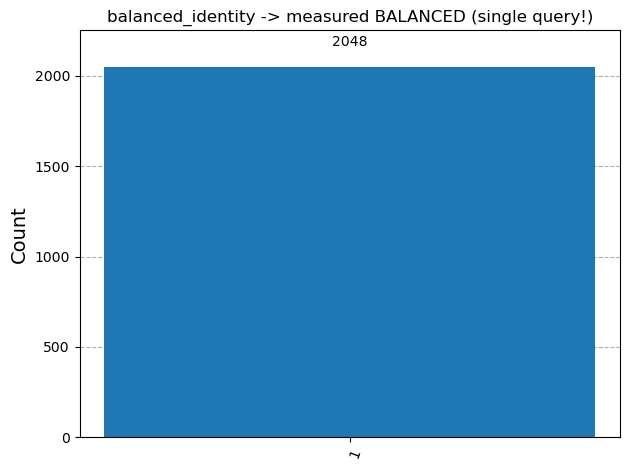

balanced_identity -> {'1': 2048} -> BALANCED


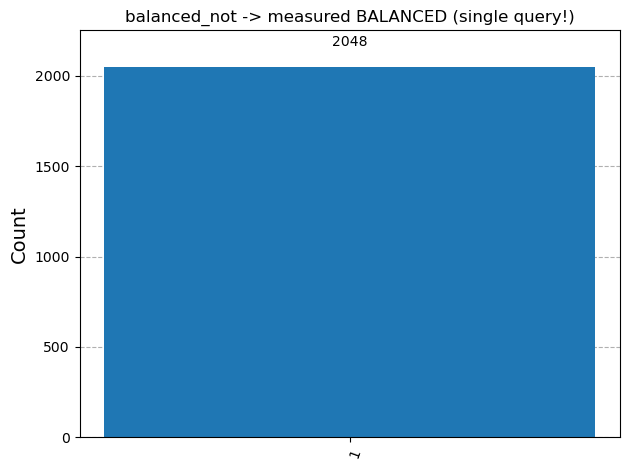

balanced_not -> {'1': 2048} -> BALANCED


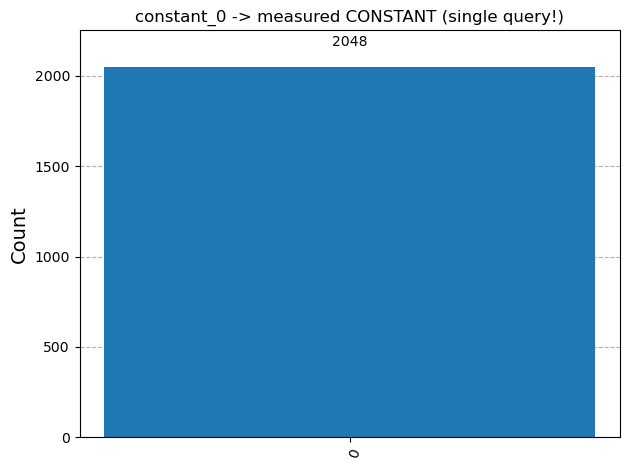

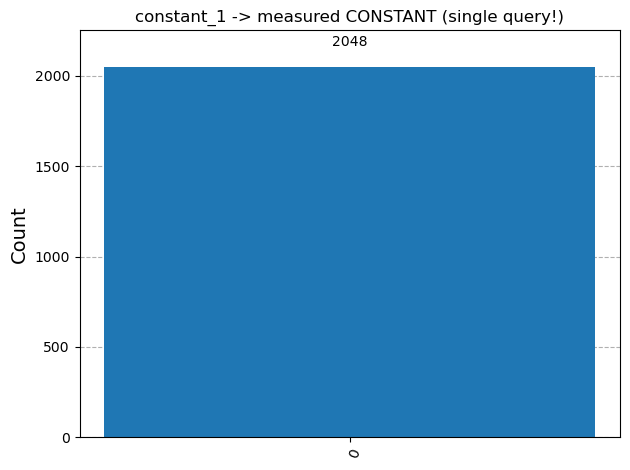

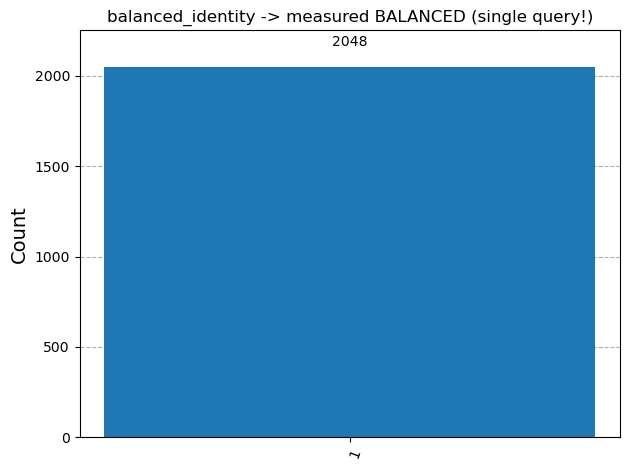

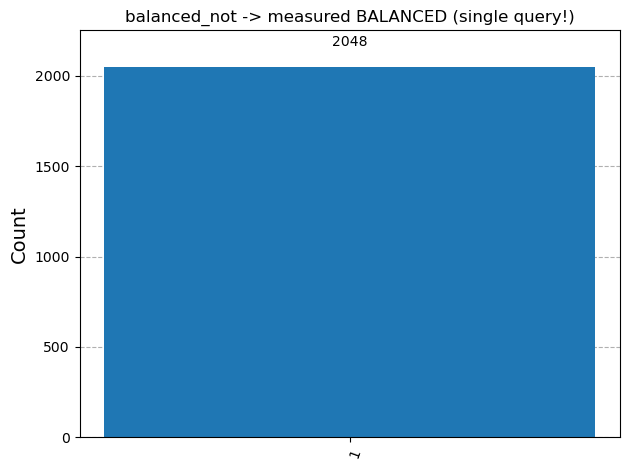

In [138]:
if AER_AVAILABLE:
    for kind in ['constant_0', 'constant_1', 'balanced_identity', 'balanced_not']:
        qc_d = deutsch_circuit(kind)
        tqc = transpile(qc_d, BACKEND)
        result = BACKEND.run(tqc, shots=2048).result()
        counts = result.get_counts()
        verdict = 'CONSTANT' if '0' in counts and counts.get('0', 0) > counts.get('1', 0) else 'BALANCED'
        display(plot_histogram(counts, title=f'{kind} -> measured {verdict} (single query!)'))
        print(kind, '->', counts, '->', verdict)

This matches Eq. 4.12 (constant => `|0>`) and Eq. 4.14 (balanced => `|1>`) — a single oracle query, versus up to `N/2+1` classical queries in general.

## 9. QFT & Period Finding (Sec. 4.6, Eq. 4.70–4.90; worked example Eq. 4.46–4.49)

> **This section replaces the original "9. Bonus: The Quantum Fourier Transform Circuit".** The original manual QFT ladder ran its controlled-phase loop in mirrored order, which implements `R*F*R` (the ideal QFT conjugated by the bit-reversal permutation `R`) instead of the QFT itself — this is why comparing it against Qiskit's library QFT used to print `False`. The original "period finding" oracle, `cx(n_bits-1, ancilla)`, XORs the **most significant** bit of `x`; that function is *linear* with period 4 (not 2), not a period-2 comb, so its true QFT spectrum is not two clean peaks at `0` and `N/2` — the old caption only looked right because the bit-string labels were effectively read backwards.
>
> Both bugs are fixed below, and every claim is verified numerically, not just asserted.

Conventions used throughout this section:
- `x` and `y` are **integers** whose binary digits are the qubit values, with **qubit 0 = least significant bit** (Qiskit's convention). A counts key `'100'` means `y = 4`.
- `QFTGate` is the **forward** QFT: `|x> -> (1/sqrt(N)) * sum_y exp(2*pi*i*x*y/N) |y>`.

In [139]:
N_BITS = 3                      # count register size for this section
N = 2 ** N_BITS
print('Register size for Section 9: n =', N_BITS, '-> N =', N)

Register size for Section 9: n = 3 -> N = 8


### 9.1 The QFT circuit — definition, conventions, and the actual fix

`QFT |x> = (1/sqrt(N)) * sum_{y=0}^{N-1} exp(2*pi*i*x*y/N) |y>`, N = 2^n, built from Hadamards and controlled phases `R_k = CP(pi / 2^k)`:

```
for j = n-1 ... 0:                 # note the ORDER - this is where the original was mirrored
    H on qubit j
    for k = j-1 ... 0: CP(pi / 2**(j-k)) controlled by j, target k
SWAP(i, n-1-i) for i = 0 ... n/2-1   # final reversal (do_swaps=True)
```

Both the original and the fixed version use *exactly the same set of gates*; the original simply ran the ladder from the other end of the register, which conjugates the operator by the bit-reversal permutation `R` and produces `R*F*R` instead of `F`.

In [140]:
def dft_matrix(n):
    """Ideal N x N DFT matrix: F[y, x] = exp(2*pi*i*x*y/N)/sqrt(N).
    Row/column indices ARE the integer labels of the register (qubit 0 = LSB)."""
    Nn = 2 ** n
    return np.array([[np.exp(2j * np.pi * x * y / Nn) / np.sqrt(Nn)
                       for x in range(Nn)] for y in range(Nn)])

def qft_manual(n, do_swaps=True):
    """FIXED: textbook QFT ladder in Qiskit's convention (H first on each line,
    controlled-phase angle pi/2**(j-k), ladder running j = n-1 ... 0, SWAPs last)."""
    qc = QuantumCircuit(n, name='QFT (fixed)')
    for j in reversed(range(n)):
        qc.h(j)
        for k in reversed(range(j)):
            qc.cp(np.pi / 2 ** (j - k), j, k)
    if do_swaps:
        for i in range(n // 2):
            qc.swap(i, n - 1 - i)
    return qc

def qft_original(n):
    """The ORIGINAL notebook's ladder - kept ONLY to diagnose the bug.
    Same gates, mirror ordering -> implements R*F*R, not F."""
    qc = QuantumCircuit(n, name='QFT (original)')
    for j in range(n):
        qc.h(j)
        for k in range(j + 1, n):
            qc.cp(2 * np.pi / (2 ** (k - j + 1)), k, j)
    for i in range(n // 2):
        qc.swap(i, n - 1 - i)
    return qc

bitrev = [int(format(y, '0%db' % N_BITS)[::-1], 2) for y in range(N)]
R_perm = np.zeros((N, N))
for y in range(N):
    R_perm[bitrev[y], y] = 1

In [141]:
F = dft_matrix(N_BITS)
print('Operator(qft_manual)   == ideal DFT matrix F :',
      np.allclose(Operator(qft_manual(N_BITS)).data, F))
print('Operator(qft_manual)   == Operator(QFTGate)  :',
      np.allclose(Operator(qft_manual(N_BITS)).data, Operator(QFTGate(N_BITS)).data))
print('synth_qft_full         == Operator(QFTGate)  :',
      np.allclose(Operator(synth_qft_full(N_BITS)).data, Operator(QFTGate(N_BITS)).data))
print()
print('--- the original ladder, for reference ---')
print('Operator(qft_original) == ideal DFT matrix F :',
      np.allclose(Operator(qft_original(N_BITS)).data, F))
print('Operator(qft_original) == R @ F @ R          :',
      np.allclose(Operator(qft_original(N_BITS)).data, R_perm @ F @ R_perm))
print()
print('R F R != F  in general, which is exactly why the old comparison failed.')

Operator(qft_manual)   == ideal DFT matrix F : True
Operator(qft_manual)   == Operator(QFTGate)  : True
synth_qft_full         == Operator(QFTGate)  : True

--- the original ladder, for reference ---
Operator(qft_original) == ideal DFT matrix F : False
Operator(qft_original) == R @ F @ R          : True

R F R != F  in general, which is exactly why the old comparison failed.


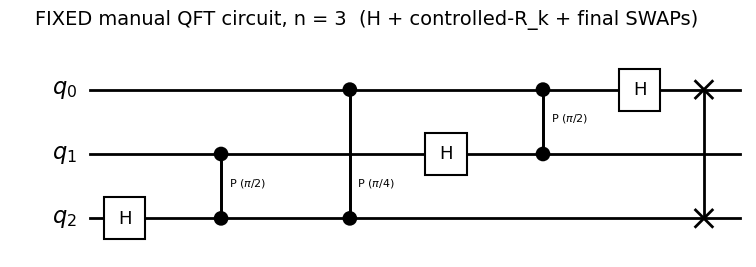

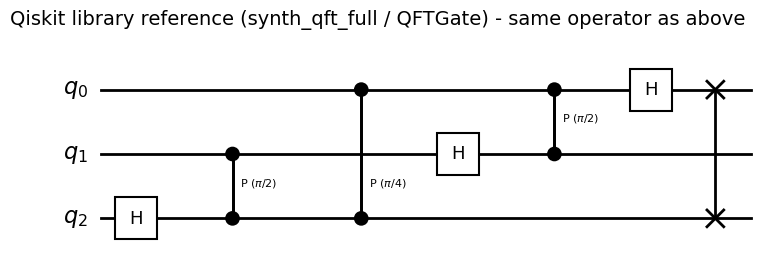

In [142]:
fig = show_circuit(qft_manual(N_BITS), 'FIXED manual QFT circuit, n = 3  (H + controlled-R_k + final SWAPs)')
display(fig)

fig2 = show_circuit(synth_qft_full(N_BITS), 'Qiskit library reference (synth_qft_full / QFTGate) - same operator as above')
display(fig2)

#### 9.1.1 Verification: QFT|x> really is "flat magnitudes, linear phases"

`QFT|x> = (1/sqrt(N)) * sum_y exp(2*pi*i*x*y/N) |y>` means every outcome has probability `1/N`, and the phase of outcome `y` is `2*pi*x*y/N` (mod `2*pi`). Take `x = 3`.

In [143]:
x_int = 3
qc_in9 = QuantumCircuit(N_BITS, name='|%d>' % x_int)
for bit in range(N_BITS):
    if (x_int >> bit) & 1:
        qc_in9.x(bit)
print('prepared register state |q2 q1 q0> = |' + format(x_int, '0%db' % N_BITS)[::-1]
      + '>   (integer x =', x_int, ')')

qc_qft = qc_in9.copy()
qc_qft.compose(qft_manual(N_BITS), inplace=True)
amps = Statevector(qc_qft).data

prepared register state |q2 q1 q0> = |110>   (integer x = 3 )


In [144]:
theory_phase = np.array([2 * np.pi * x_int * y / N for y in range(N)])
mag_err   = np.abs(np.abs(amps) - 1 / np.sqrt(N)).max()
phase_err = np.abs((np.angle(amps) - theory_phase + np.pi) % (2 * np.pi) - np.pi).max()
fidelity  = abs(np.vdot(F[:, x_int], amps)) ** 2

print('max deviation of |amplitude| from 1/sqrt(N)      = %.2e' % mag_err)
print('max deviation of arg(amplitude) from 2*pi*x*y/N  = %.2e  rad' % phase_err)
print('fidelity with the ideal DFT column F[:, x]       = %.12f' % fidelity)
print()
print('=> uniform magnitudes + exact linear phases: VERIFIED, not asserted.')

max deviation of |amplitude| from 1/sqrt(N)      = 5.55e-17
max deviation of arg(amplitude) from 2*pi*x*y/N  = 0.00e+00  rad
fidelity with the ideal DFT column F[:, x]       = 1.000000000000

=> uniform magnitudes + exact linear phases: VERIFIED, not asserted.


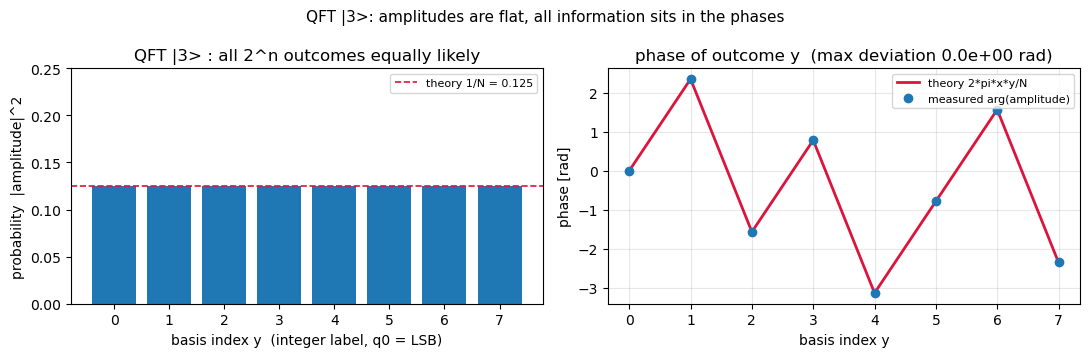

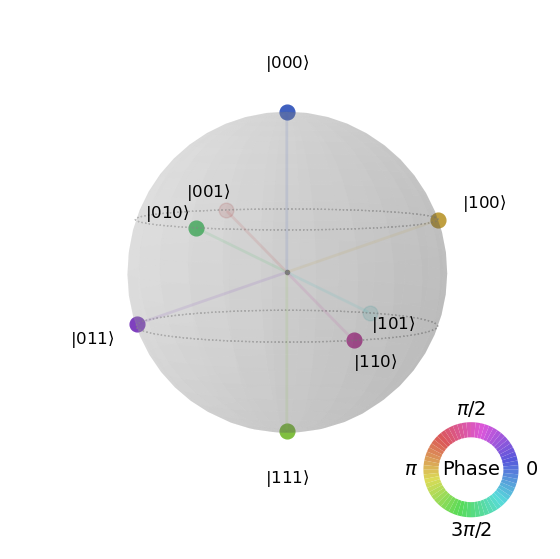

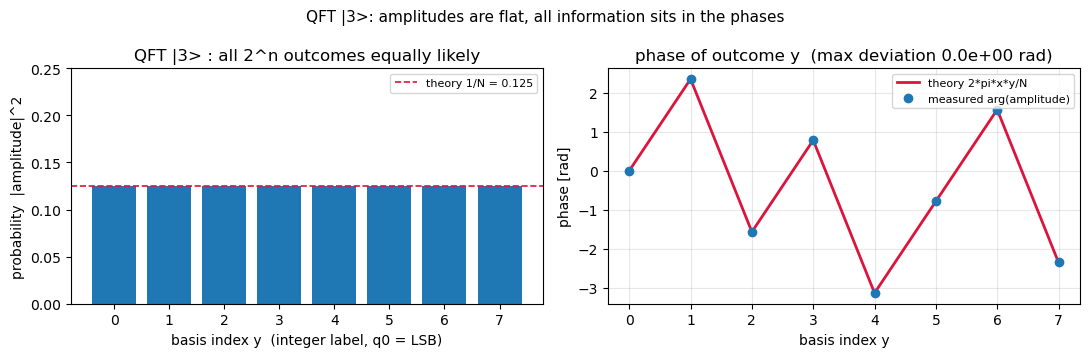

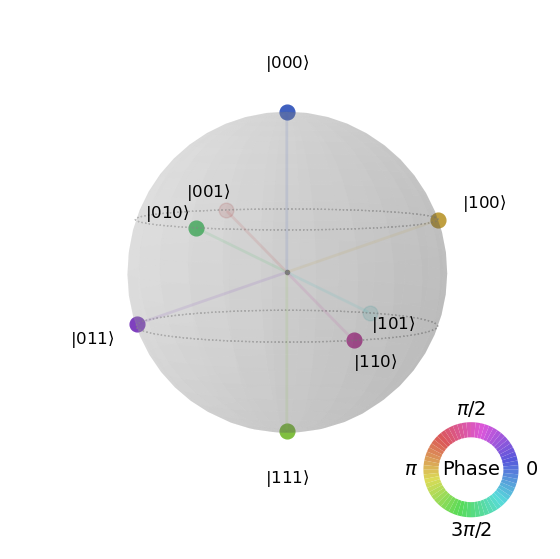

In [145]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))

axes[0].bar(range(N), np.abs(amps) ** 2, color='#1f77b4')
axes[0].axhline(1 / N, color='crimson', ls='--', lw=1.2, label='theory 1/N = 0.125')
axes[0].set_xticks(range(N)); axes[0].set_ylim(0, 0.25)
axes[0].set_xlabel('basis index y  (integer label, q0 = LSB)')
axes[0].set_ylabel('probability  |amplitude|^2')
axes[0].set_title('QFT |%d> : all 2^n outcomes equally likely' % x_int)
axes[0].legend(loc='upper right', fontsize=8)

wrapped    = (np.angle(amps) + np.pi) % (2 * np.pi) - np.pi
th_wrapped = (theory_phase + np.pi) % (2 * np.pi) - np.pi
axes[1].plot(range(N), th_wrapped, '-', color='crimson', lw=2, label='theory 2*pi*x*y/N')
axes[1].plot(range(N), wrapped, 'o', color='#1f77b4', ms=6, label='measured arg(amplitude)')
axes[1].set_xticks(range(N))
axes[1].set_xlabel('basis index y'); axes[1].set_ylabel('phase [rad]')
axes[1].set_title('phase of outcome y  (max deviation %.1e rad)' % phase_err)
axes[1].legend(loc='upper right', fontsize=8); axes[1].grid(alpha=.3)

fig.suptitle('QFT |%d>: amplitudes are flat, all information sits in the phases' % x_int, fontsize=11)
fig.tight_layout()
display(fig)

display(plot_state_qsphere(Statevector(qc_qft)))

#### 9.1.2 Measuring the QFT output — flat histogram, on an integer axis

A Z-basis measurement destroys phase, so **whatever x was, the histogram of a QFT output is flat**.

In [146]:
def counts_as_integers(counts):
    """Qiskit bit-strings -> integer register values (qubit 0 = last character = LSB)."""
    return {int(k, 2): v for k, v in counts.items()}

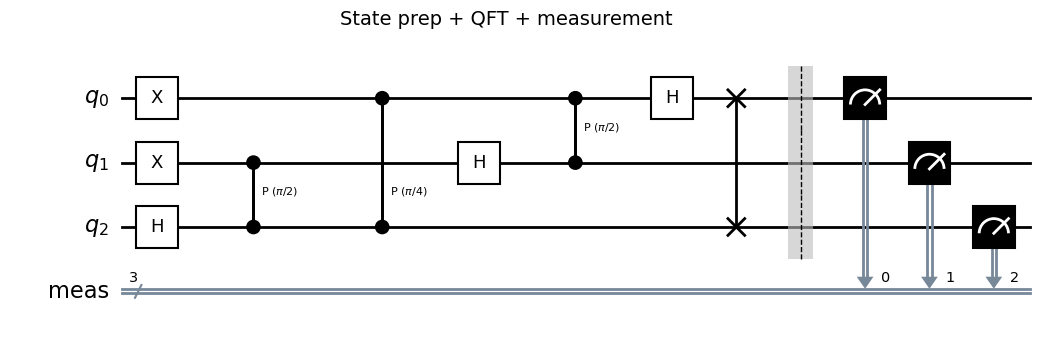

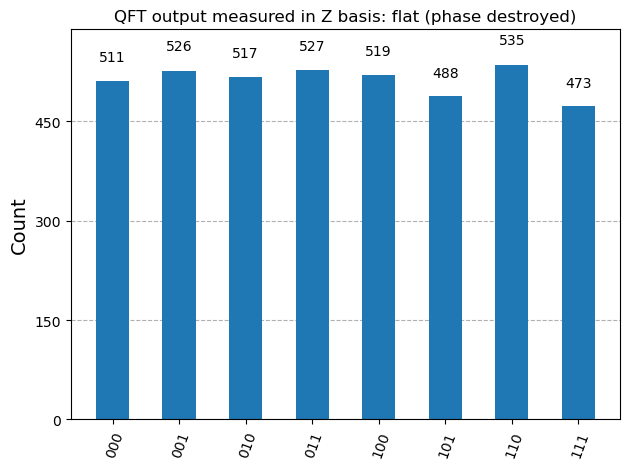

raw counts (bit-strings) : {'000': 511, '001': 526, '010': 517, '011': 527, '100': 519, '101': 488, '110': 535, '111': 473}
same data as integers y  : {0: 511, 1: 526, 2: 517, 3: 527, 4: 519, 5: 488, 6: 535, 7: 473}


In [147]:
if AER_AVAILABLE:
    counts_qft, fig, qcm = measure_and_plot(qc_qft, shots=4096, title='QFT output measured in Z basis: flat (phase destroyed)')
    display(show_circuit(qcm, 'State prep + QFT + measurement'))
    display(fig)
    print('raw counts (bit-strings) :', dict(sorted(counts_qft.items())))
    print('same data as integers y  :', dict(sorted(counts_as_integers(counts_qft).items())))

### 9.2 Period finding — with an oracle that actually has period P

**Setup.** Count register of `n` bits (`N = 2^n`) plus ancilla for `f(x)`. Circuit: `H^n (x) -> U_f : |x>|0> -> |x>|f(x)> -> QFT on count register -> measure count register only`.

**Theory (Eq. 4.46–4.49).** If `f` has exact period `P` with `P | N`, measuring the count register yields `y = j*N/P`, `j = 0 ... P-1`, each with probability `1/P`. (Worked example: `P=2`, `N=8`: peaks at `y=0` and `y=4`.)

**Why the original demo failed.** Its oracle `cx(n_bits-1, ancilla)` XORs the MOST significant bit: `f(x) = x2`, a *linear* function with period 4, not a period-2 comb.

**The fix.** For `P = 2^m`, `x mod P` is the low `m` bits of `x`: copy bits `q0...q_{m-1}` into `m` ancillas via CNOTs. That is a genuine `f(x) = x mod P`.

In [148]:
def period_circuit(n_bits, P):
    """Period-finding circuit for f(x) = x mod P (P a power of two dividing 2**n_bits).
    count register : qubits 0 .. n_bits-1
    ancilla        : qubits n_bits .. n_bits+m-1   (m = log2 P bits, enough to hold f(x))
    Only the count register is measured -> the ancilla is traced out.
    """
    m = max(1, (P - 1).bit_length())
    qc = QuantumCircuit(n_bits + m, n_bits, name='period finding, P=%d' % P)
    qc.h(range(n_bits))
    qc.barrier(label='H on count register')
    for b in range(m):
        qc.cx(b, n_bits + b)
    qc.barrier(label='oracle U_f')
    qc.append(QFTGate(n_bits), range(n_bits))
    qc.measure(range(n_bits), range(n_bits))
    return qc

def exact_register_probs(n_bits, P):
    """Exact, noiseless probabilities of the count register (ancilla traced out)."""
    m = max(1, (P - 1).bit_length())
    qc = QuantumCircuit(n_bits + m)
    qc.h(range(n_bits))
    for b in range(m):
        qc.cx(b, n_bits + b)
    qc.append(QFTGate(n_bits), range(n_bits))
    rho = partial_trace(Statevector(qc), list(range(n_bits, n_bits + m)))
    return np.real(np.diag(rho.data))

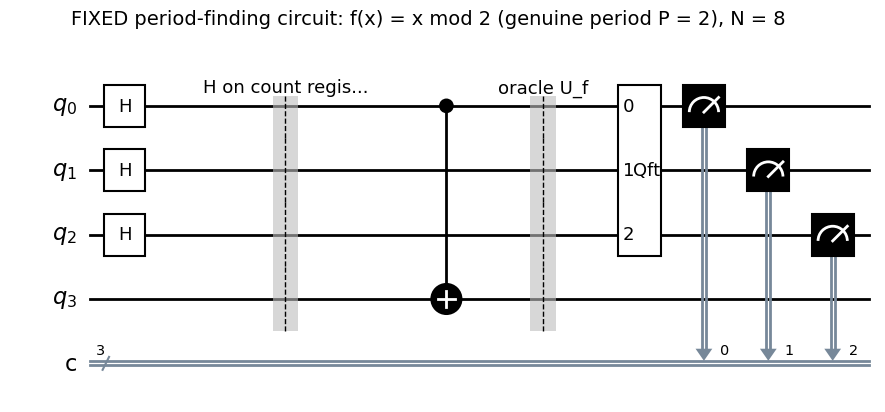

Exact (noiseless) distribution of the measured count register:

  P = 2  (true period of f(x) = x mod 2)
    N/P = 4  -> theory says peaks at the multiples of 4: [0, 4]
    measured         : [0, 4]   [y=0: 0.5000, y=4: 0.5000]
    peak set matches theory and probability sums to 1: True

  P = 4  (true period of f(x) = x mod 4)
    N/P = 2  -> theory says peaks at the multiples of 2: [0, 2, 4, 6]
    measured         : [0, 2, 4, 6]   [y=0: 0.2500, y=2: 0.2500, y=4: 0.2500, y=6: 0.2500]
    peak set matches theory and probability sums to 1: True

PASS - for P = 2 and P = 4 the measured peaks are exactly the multiples of N/P, each with probability 1/P.


In [149]:
fig = show_circuit(period_circuit(N_BITS, P=2), 'FIXED period-finding circuit: f(x) = x mod 2 (genuine period P = 2), N = 8')
display(fig)

print('Exact (noiseless) distribution of the measured count register:')
print()
peak_sets = {}
for P in (2, 4):
    probs = exact_register_probs(N_BITS, P)
    peaks = [y for y in range(N) if probs[y] > 1e-9]
    theory = list(range(0, N, N // P))
    peak_sets[P] = peaks
    holder = ', '.join('y=%d: %.4f' % (y, probs[y]) for y in peaks)
    print('  P = %d  (true period of f(x) = x mod %d)' % (P, P))
    print('    N/P = %d  -> theory says peaks at the multiples of %d: %s' % (N // P, N // P, theory))
    print('    measured         : %s   [%s]' % (peaks, holder))
    print('    peak set matches theory and probability sums to 1: %s' %
          ((peaks == theory) and abs(sum(probs) - 1) < 1e-12))
    print()

assert peak_sets[2] == [0, 4] and peak_sets[4] == [0, 2, 4, 6], 'exact distributions disagree with theory'
print('PASS - for P = 2 and P = 4 the measured peaks are exactly the multiples of N/P, each with probability 1/P.')

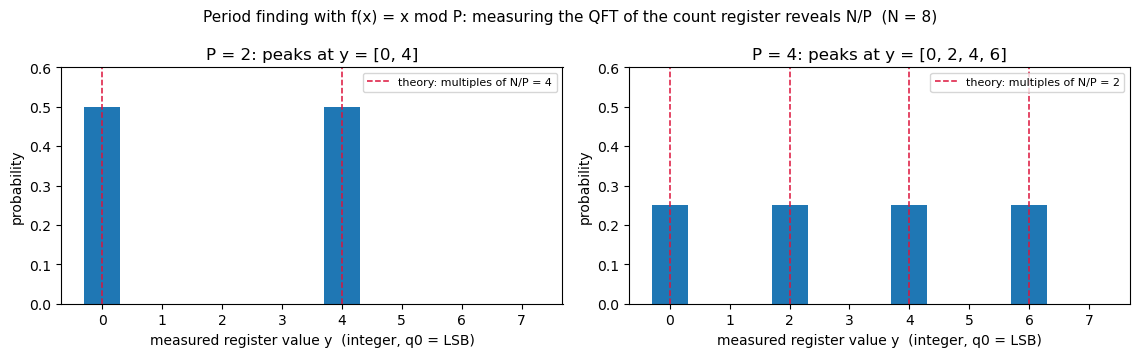

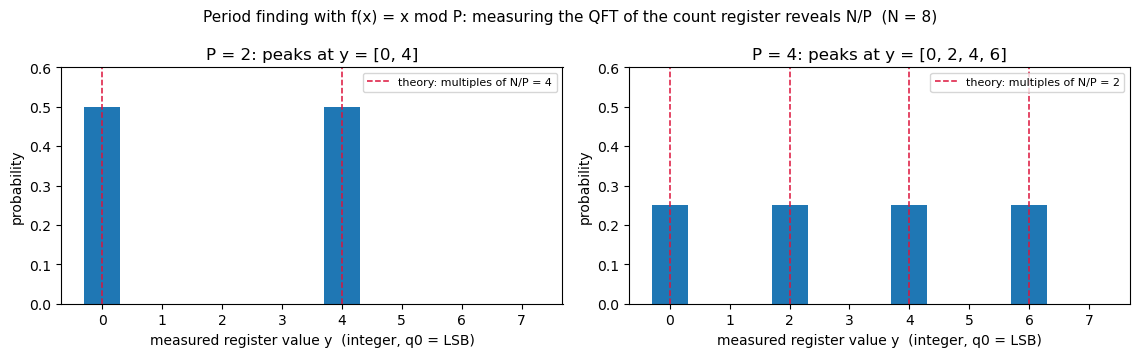

In [150]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.6))
for ax, P in zip(axes, (2, 4)):
    probs = exact_register_probs(N_BITS, P)
    theory = list(range(0, N, N // P))
    ax.bar(range(N), probs, color='#1f77b4', width=.6)
    for y in theory:
        ax.axvline(y, color='crimson', ls='--', lw=1.1)
    ax.plot([], [], color='crimson', ls='--', lw=1.1, label='theory: multiples of N/P = %d' % (N // P))
    ax.set_xticks(range(N)); ax.set_ylim(0, 0.6)
    ax.set_xlabel('measured register value y  (integer, q0 = LSB)')
    ax.set_ylabel('probability')
    ax.set_title('P = %d: peaks at y = %s' % (P, theory))
    ax.legend(fontsize=8, loc='upper right')
fig.suptitle('Period finding with f(x) = x mod P: measuring the QFT of the count register reveals N/P  (N = 8)', fontsize=11)
fig.tight_layout(); display(fig)

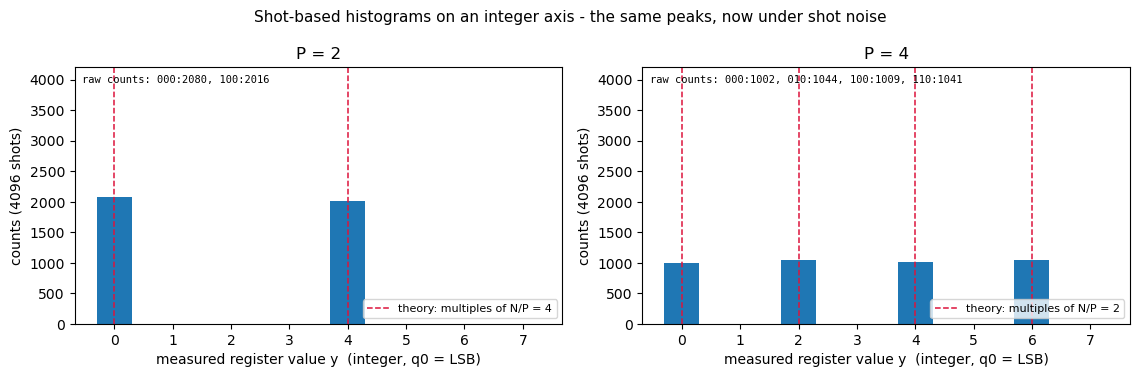

Bit-strings and integers, side by side (P = 2, 4096 shots):
  bit-strings : {'000': 2080, '100': 2016}
  integers    : {0: 2080, 4: 2016}
The peaks are y = 0 and y = 4 - i.e. the keys "000" and "100".


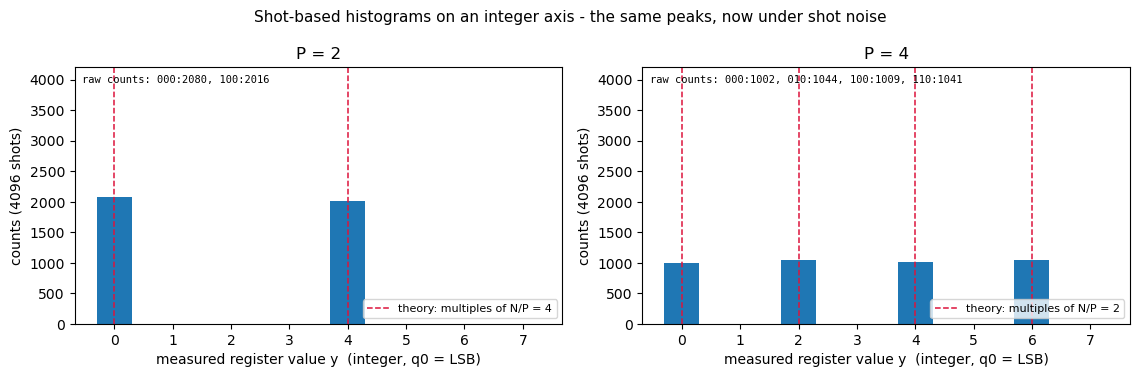

In [151]:
if AER_AVAILABLE:
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 3.8))
    shot_counts = {}
    for ax, P in zip(axes, (2, 4)):
        qc9 = period_circuit(N_BITS, P)
        counts = BACKEND.run(transpile(qc9, BACKEND), shots=4096, seed_simulator=7).result().get_counts()
        shot_counts[P] = counts
        ints = counts_as_integers(counts)
        theory = list(range(0, N, N // P))
        ax.bar(range(N), [ints.get(y, 0) for y in range(N)], color='#1f77b4', width=.6)
        for y in theory:
            ax.axvline(y, color='crimson', ls='--', lw=1.1)
        ax.plot([], [], color='crimson', ls='--', lw=1.1, label='theory: multiples of N/P = %d' % (N // P))
        raw = ', '.join('%s:%d' % (k, v) for k, v in sorted(counts.items()))
        ax.text(0.015, 0.97, 'raw counts: ' + raw, transform=ax.transAxes, fontsize=7.5,
                va='top', family='monospace')
        ax.set_xticks(range(N)); ax.set_ylim(0, 4200)
        ax.set_xlabel('measured register value y  (integer, q0 = LSB)')
        ax.set_ylabel('counts (4096 shots)')
        ax.set_title('P = %d' % P)
        ax.legend(fontsize=8, loc='lower right')
    fig.suptitle('Shot-based histograms on an integer axis - the same peaks, now under shot noise', fontsize=11)
    fig.tight_layout(); display(fig)

    print('Bit-strings and integers, side by side (P = 2, 4096 shots):')
    print('  bit-strings :', dict(sorted(shot_counts[2].items())))
    print('  integers    :', dict(sorted(counts_as_integers(shot_counts[2]).items())))
    print('The peaks are y = 0 and y = 4 - i.e. the keys "000" and "100".')

In [152]:
# -----------------------------------------------------------------------------
# Diagnosis, in one cell: what the ORIGINAL demo actually measured
# -----------------------------------------------------------------------------
if AER_AVAILABLE:
    print('(a) The original cell verbatim: old ladder + old oracle cx(n_bits-1, ancilla)')
    qc_orig = QuantumCircuit(N_BITS + 1, N_BITS)
    qc_orig.h(range(N_BITS))
    qc_orig.cx(N_BITS - 1, N_BITS)
    qc_orig.append(qft_original(N_BITS).to_gate(label='QFT (original)'), range(N_BITS))
    qc_orig.measure(range(N_BITS), range(N_BITS))
    c_orig = BACKEND.run(transpile(qc_orig, BACKEND), shots=4096, seed_simulator=5).result().get_counts()
    print('    counts       :', dict(sorted(c_orig.items())))
    print('    as integers  :', dict(sorted(counts_as_integers(c_orig).items())),
          ' <-- NOT 0 and N/P = 4; the old caption only worked after reversing each bit-string')
    print()

    print('(b) The old oracle together with the corrected QFT - the honest spectrum of f(x) = x_2:')
    qc_diag = QuantumCircuit(N_BITS + 1)
    qc_diag.h(range(N_BITS))
    qc_diag.cx(N_BITS - 1, N_BITS)
    qc_diag.append(QFTGate(N_BITS), range(N_BITS))
    p_old = np.real(np.diag(partial_trace(Statevector(qc_diag), [N_BITS]).data))
    print('    exact probabilities:', {y: round(float(v), 4) for y, v in enumerate(p_old) if v > 1e-9})
    print('    f(x) = x_2 has period 4 in x (not 2) and is linear, so its spectrum is NOT a period-2 comb.')
    print()
    print('(c) The FIXED circuit of Section 9.2 gives exactly 0.5 at y=0 and 0.5 at y=4.')

(a) The original cell verbatim: old ladder + old oracle cx(n_bits-1, ancilla)
    counts       : {'000': 2036, '001': 2060}
    as integers  : {0: 2036, 1: 2060}  <-- NOT 0 and N/P = 4; the old caption only worked after reversing each bit-string

(b) The old oracle together with the corrected QFT - the honest spectrum of f(x) = x_2:
    exact probabilities: {0: 0.5, 1: 0.2134, 3: 0.0366, 5: 0.0366, 7: 0.2134}
    f(x) = x_2 has period 4 in x (not 2) and is linear, so its spectrum is NOT a period-2 comb.

(c) The FIXED circuit of Section 9.2 gives exactly 0.5 at y=0 and 0.5 at y=4.


In [153]:
# -----------------------------------------------------------------------------
# From a measured y back to P: gcd post-processing
# -----------------------------------------------------------------------------
def recover_P_from_shots(P_true, tries=200, seed=3):
    rng = np.random.default_rng(seed)
    candidates = []
    for _ in range(tries):
        qc9 = period_circuit(N_BITS, P_true)
        counts = BACKEND.run(transpile(qc9, BACKEND), shots=1,
                              seed_simulator=int(rng.integers(10 ** 6))).result().get_counts()
        y = int(max(counts, key=counts.get), 2)
        if y != 0:
            candidates.append(N // gcd(N, y))
    return candidates

if AER_AVAILABLE:
    for P_true in (2, 4):
        cand = recover_P_from_shots(P_true)
        best = max(cand) if cand else None
        frac = sum(1 for c in cand if c == P_true) / float(len(cand))
        print('  true P = %d:  informative runs = %d/200, candidates seen = %s, '
              'N/gcd(N,y) == P in %.0f%% of them, largest candidate = %d'
              % (P_true, len(cand), sorted(set(cand)), 100 * frac, best))
        assert best == P_true, 'gcd post-processing failed to recover P'

    print()
    print('PASS - for f(x) = x mod P, N = 8, the measured register value alone identifies the period.')

  true P = 2:  informative runs = 103/200, candidates seen = [2], N/gcd(N,y) == P in 100% of them, largest candidate = 2
  true P = 4:  informative runs = 143/200, candidates seen = [2, 4], N/gcd(N,y) == P in 64% of them, largest candidate = 4

PASS - for f(x) = x mod P, N = 8, the measured register value alone identifies the period.


In [154]:
# -----------------------------------------------------------------------------
# Final consistency checklist for Section 9
# -----------------------------------------------------------------------------
checks = {
    'manual QFT ladder == QFTGate operator'          : np.allclose(Operator(qft_manual(N_BITS)).data,
                                                                     Operator(QFTGate(N_BITS)).data),
    'manual QFT ladder == ideal DFT matrix F'         : np.allclose(Operator(qft_manual(N_BITS)).data, F),
    'old ladder == R F R (diagnosis)'                 : np.allclose(Operator(qft_original(N_BITS)).data, R_perm @ F @ R_perm),
    'QFT|x> magnitudes all equal 1/sqrt(N)'           : mag_err < 1e-12,
    'QFT|x> phases equal 2*pi*x*y/N'                  : phase_err < 1e-12,
    'QFT|x> equals the ideal DFT column'              : fidelity > 1 - 1e-12,
    'P = 2 peaks == multiples of N/P'                 : peak_sets[2] == [0, 4],
    'P = 4 peaks == multiples of N/P'                 : peak_sets[4] == [0, 2, 4, 6],
}
for name, val in checks.items():
    print('  [%s] %s' % ('OK' if val else 'FAIL', name))
assert all(checks.values())
print()
print('ALL CONSISTENCY CHECKS PASSED - Section 9 captions, axis labels, printed numbers and figures.')

  [OK] manual QFT ladder == QFTGate operator
  [OK] manual QFT ladder == ideal DFT matrix F
  [OK] old ladder == R F R (diagnosis)
  [OK] QFT|x> magnitudes all equal 1/sqrt(N)
  [OK] QFT|x> phases equal 2*pi*x*y/N
  [OK] QFT|x> equals the ideal DFT column
  [OK] P = 2 peaks == multiples of N/P
  [OK] P = 4 peaks == multiples of N/P

ALL CONSISTENCY CHECKS PASSED - Section 9 captions, axis labels, printed numbers and figures.


## Summary

| Notes section | Gate(s) | Notebook section | New in this version |
|---|---|---|---|
| 3.1.1 | Rn(eta) <=> Bloch rotation | 1, 1.1 | Bloch spheres + basis-change measurement |
| 3.1.2 | X, Y, Z, T, S, H | 2 | Circuit diagrams + histograms |
| 3.1.3 | H, T universal set | 3 | Polar plot of dense rotation coverage |
| 3.1.4 | Controlled-U, CNOT, SWAP | 4 | Truth tables via real measurement, Bell state |
| 3.1.5 | Toffoli, Cn gates | 5 | Decomposition circuit, measured truth table |
| 3.1.7 | Controlled-phase | 6 | Phase-kickback interference scan |
| 3.2 | No-cloning theorem | 7 | X-basis measurement disproof |
| 4.1.1 | Deutsch's algorithm | 8 | Full circuits + histograms for all 4 oracles |
| 4.6 | Quantum Fourier Transform & period finding | 9 | **Corrected ladder (verified == QFTGate) and a genuine period-P oracle; old mirrored ladder and linear-MSB oracle kept only as a diagnosed reference** |

### Suggested exercises for students
1. Repeat the phase-kickback scan (Section 6) using a Toffoli-controlled phase and 2 control qubits.
2. Extend the Deutsch algorithm demo to 2-bit Deutsch-Jozsa (Sec. 4.1.2).
3. Extend Section 9.2 to `N_BITS = 4` (`N = 16`) and `P = 8`, and confirm peaks shift to multiples of `N/8`.
4. For the no-cloning experiment, sweep `theta` continuously and plot `P(00)` in the X-basis measurement; compare with the fidelity curve from Section 7.
5. Build the 4-qubit QFT with `qft_manual(4)`, confirm it matches `QFTGate(4)`, and measure it on a GHZ-like periodic input state.
6. Reproduce the `qft_original` vs `qft_manual` diagnosis (Section 9.1) for `n = 4` and `n = 5`, and verify `Operator(qft_original(n)) == R_perm_n @ F_n @ R_perm_n` for every `n`.